#  - Greenfield Ammoniak Patagonien -

# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from oemof import solph
from oemof.tools import economics
import matplotlib.dates as mdates


# Farbeinstellungen

In [3]:
# Sektoren: col_el, col_chem, col_h2, col_n2, col_nh3
# Technologien: col_pem, col_pv, col_asu, col_hb, col_wka, col_h2s, col_bat
# Bilanz: col_sell, col_buy
# Sonstige: col_etc

col_n2 = col_asu = "#e5742e"                # Corporate orange              oder Gas orange: "#e4932c"
col_pv = "#e4cb3a"                          # PV Gelb
col_wka = "#128fcf"                         # WKA Blau
col_h2 = col_pem = "#14689b"                # Corporate Blau                oder Wasser blau: "#1b5aa6"
col_nh3 = col_hb = "#822181"                # Corporate Lila                oder Fern/Nahwärme Lila: "#8f2f89"
col_h2s = "#79CADD"                         # Corporate Hellblau 
col_bat = "#8CBF3E"                         # ElChem Speicher grün
col_buy = "#505050"
col_chem = "#1D9838"              # Biomasse Grün
col_etc = "#828282"                         # Corporate Grau
col_el= col_sell = "#E02229"                # Stromsektor Rot 

# 1 Eingangsdaten

In [ ]:
volllaststunden = pd.read_csv("Lastprofile.csv", sep=';', decimal=',')

Eingangsdaten_df = pd.read_excel("Datenbank.xlsx", sheet_name="Datenauswahl", decimal=',')
Eingangsdaten_df.set_index("Variable", inplace=True)   
Eingangsdaten = Eingangsdaten_df["Wert"].to_dict()

Ergebnisse_df = pd.read_excel("Datenbank.xlsx", sheet_name="Ergebnisse", decimal=',')
Ergebnisse_df.set_index("Variable", inplace=True)

#Anpassung der Zinssätze auf Chile 
aufschlag = 0.008 #Wert auf Basis von Damoran Länder Risiken

zinssatz_keys = [
    "zinssatz_hb",
    "zinssatz_asu",
    "zinssatz_h2s",
    "zinssatz_pem",
    "zinssatz_bat",
    "zinssatz_wkaon",
    "zinssatz_pv",
]

Eingangsdaten_df.loc[zinssatz_keys, "Wert"] += aufschlag

Eingangsdaten = Eingangsdaten_df["Wert"].to_dict()



##  1.1 Darstellung Eingangsdaten

### 1.1.1 Profile

<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
C:\Users\hem38994\AppData\Local\Temp\ipykernel_35916\596485935.py:39: SyntaxWarning: invalid escape sequence '\e'
  plt.savefig("Bilder\eingangsdaten_einspeise_lastprofile.png", dpi=300, bbox_inches='tight')


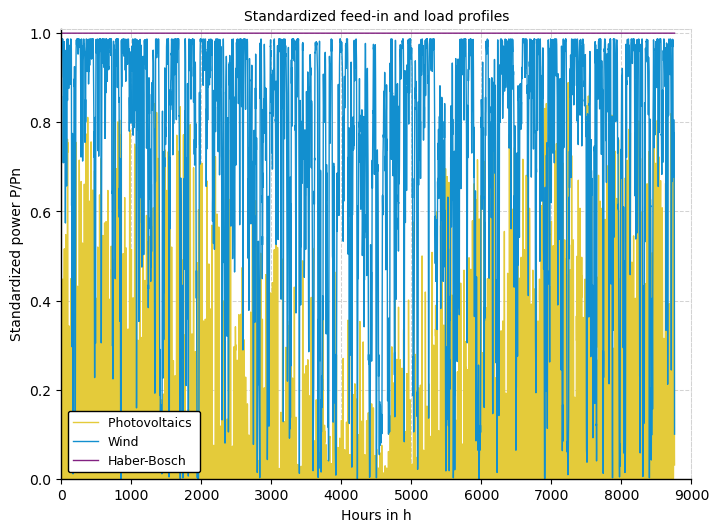

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(volllaststunden['PV Patagonien'], label="Photovoltaics ", color=col_pv, linewidth=1)
plt.plot(volllaststunden['Wind Patagonien'], label="Wind", color=col_wka, linewidth=1)
plt.plot(volllaststunden['Volllast'], label="Haber-Bosch", color=col_hb, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(0, 1.01)
plt.xlim(0, 9000)

plt.title("Standardized feed-in and load profiles", fontsize=10)
plt.xlabel("Hours in h", fontsize=10)
plt.ylabel("Standardized power P/Pn", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='lower left', fontsize=9, frameon=True, edgecolor='black', facecolor='white', framealpha=1)
plt.savefig("Bilder\eingangsdaten_einspeise_lastprofile.png", dpi=300, bbox_inches='tight')
plt.show()



### 1.1.2 CAPEX

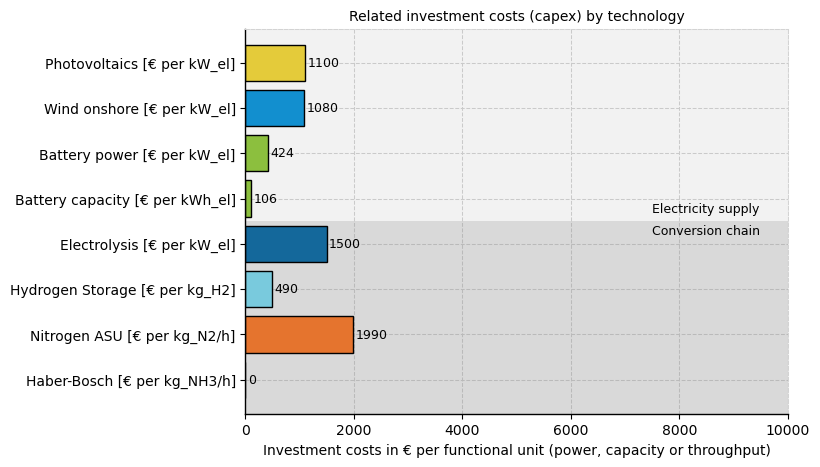

In [6]:
categories = [
    "Haber-Bosch [€ per kg_NH3/h]", "Nitrogen ASU [€ per kg_N2/h]", "Hydrogen Storage [€ per kg_H2]", "Electrolysis [€ per kW_el]",
    "Battery capacity [€ per kWh_el]", "Battery power [€ per kW_el]", "Wind onshore [€ per kW_el]", "Photovoltaics [€ per kW_el]"
]

values = [
    Eingangsdaten["capex_hb"], Eingangsdaten["capex_asu"], Eingangsdaten["capex_h2s"], Eingangsdaten["capex_pem"],
    Eingangsdaten["capex_bat_kapa"], Eingangsdaten["capex_bat_leistung"], Eingangsdaten["capex_wkaon"], Eingangsdaten["capex_pv"]
]

colors = [col_hb, col_asu, col_h2s, col_pem, col_bat, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 3.5
ax.axhspan(cut, 8, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(categories)-0.25])
ax.text(7500, cut+0.2, "Electricity supply", fontsize=9, color="black")  
ax.text(7500, cut-0.3, "Conversion chain", fontsize=9, color="black")

# boundary_y = 3.5  # Grenze zwischen "Conversion chain" und "Electricity supply"
# ax.plot([0, 10000], [boundary_y, boundary_y], color='black', linewidth=0.5, linestyle='--')

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:.0f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Investment costs in € per functional unit (power, capacity or throughput)", fontsize=10)
plt.title("Related investment costs (capex) by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 10000])

plt.savefig("Bilder/eingangsdaten_capex_bar.png", dpi=300, bbox_inches='tight')

### 1.1.3 OPEX

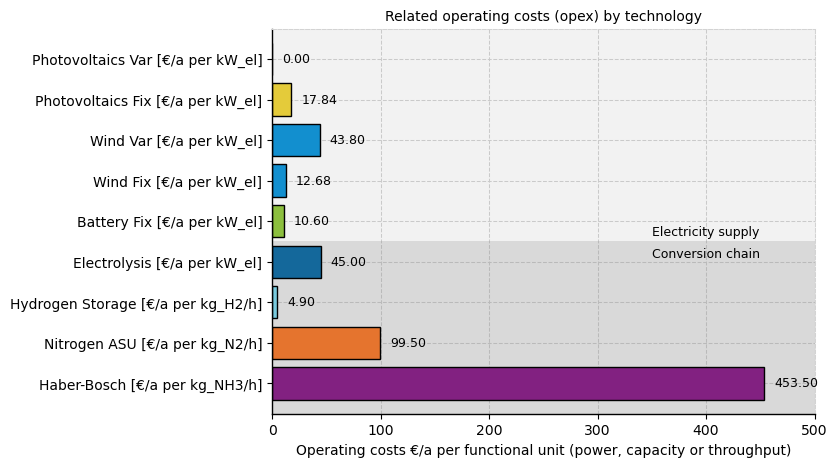

In [7]:
categories_opex = [
"Haber-Bosch [€/a per kg_NH3/h]", "Nitrogen ASU [€/a per kg_N2/h]", "Hydrogen Storage [€/a per kg_H2/h]", "Electrolysis [€/a per kW_el]",
"Battery Fix [€/a per kW_el]", "Wind Fix [€/a per kW_el]", "Wind Var [€/a per kW_el]",
"Photovoltaics Fix [€/a per kW_el]", "Photovoltaics Var [€/a per kW_el]"
]

values_opex = [
Eingangsdaten["opex_hb"] ,#* Eingangsdaten["capex_hb"], # %/a * €/kg_NH3 *h = €/a pro kg/h
Eingangsdaten["opex_asu"] * Eingangsdaten["capex_asu"], # %/a * €/kg_N2 *h = €/a pro kg/h
Eingangsdaten["opex_h2s"] * Eingangsdaten["capex_h2s"], # %/a * €/kg_H2 * h = €/a pro kg/h
Eingangsdaten["opex_pem"] * Eingangsdaten["capex_pem"], # %/a * €/kW_el = €/kWa
Eingangsdaten["opex_fix_bat"] * Eingangsdaten["capex_bat_leistung"], # %/a * €/kW_el = €/kWa
Eingangsdaten["opex_fix_wkaon"], # €/kWa
Eingangsdaten["opex_var_wkaon"] * 8760, # €/kWh *8760h/a = €/kWa
Eingangsdaten["opex_fix_pv"], # €/kWa
Eingangsdaten["opex_var_pv"] * 8760 # €/kWh *8760h/a = €/kWa
]

colors_opex = [col_hb, col_asu, col_h2s, col_pem, col_bat, col_wka, col_wka, col_pv, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(3.5, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 3.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(categories_opex)-0.25])
ax.text(350, 3.65, "Electricity supply", fontsize=9, color="black")  
ax.text(350, 3.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories_opex, values_opex, color=colors_opex, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values_opex) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Operating costs €/a per functional unit (power, capacity or throughput)", fontsize=10)
plt.title("Related operating costs (opex) by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 500])

plt.savefig("Bilder/eingangsdaten_opex_bar.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.1.4 Wirkungsgrade

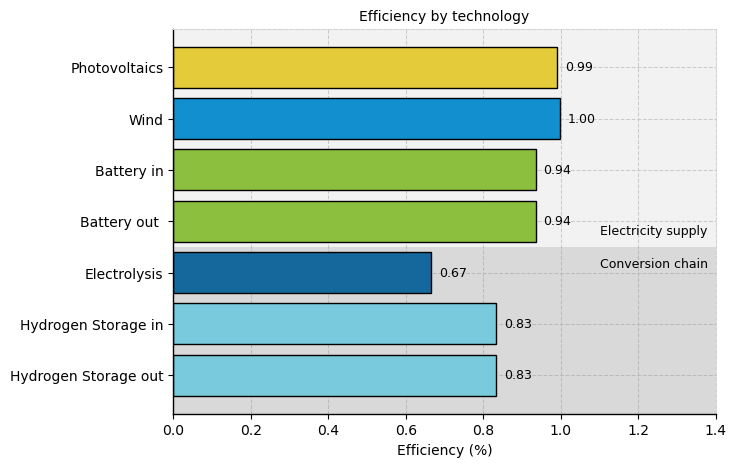

In [8]:
eta_params = ["Hydrogen Storage out", "Hydrogen Storage in","Electrolysis", "Battery out ","Battery in", "Wind", "Photovoltaics"]
eta_values = [Eingangsdaten["eta_ausspeichern_h2s"],Eingangsdaten["eta_einspeichern_h2s"],Eingangsdaten["eta_pem"],Eingangsdaten["eta_ausspeichern_bat"],Eingangsdaten["eta_einspeichern_bat"],Eingangsdaten["eta_wkaon"],Eingangsdaten["eta_pv"]]
eta_colors = [col_h2s,col_h2s,col_pem, col_bat, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(2.5, 8, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 2.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(eta_values)-0.25])
ax.text(1.1, 2.75, "Electricity supply", fontsize=9, color="black")  
ax.text(1.1, 2.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(eta_params, eta_values, color=eta_colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(eta_values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Efficiency (%)", fontsize=10)
plt.title("Efficiency by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 1.4])

plt.savefig("Bilder/eingangsdaten_eta_bar.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.1.5 Zinssätze

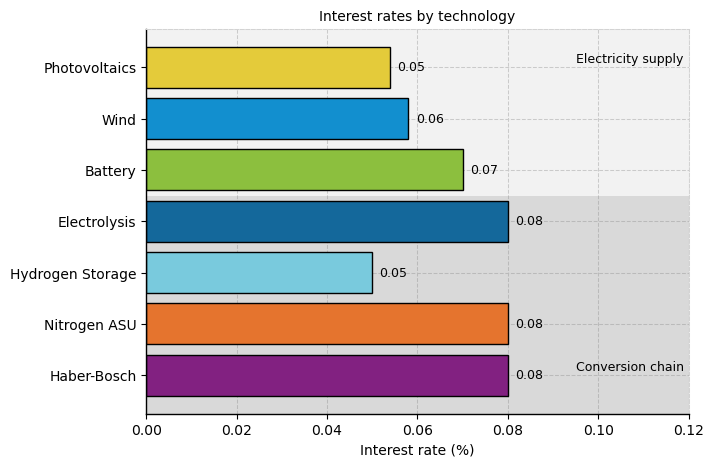

In [9]:
zins_params = ["Haber-Bosch","Nitrogen ASU", "Hydrogen Storage","Electrolysis", "Battery", "Wind", "Photovoltaics"]
zins_values = [Eingangsdaten["zinssatz_hb"],Eingangsdaten["zinssatz_asu"],Eingangsdaten["zinssatz_h2s"],Eingangsdaten["zinssatz_pem"],Eingangsdaten["zinssatz_bat"], Eingangsdaten["zinssatz_wkaon"],Eingangsdaten["zinssatz_pv"]]
zins_colors = [col_hb,col_asu,col_h2s,col_pem, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(3.5, 7, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 3.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(zins_values)-0.25])
ax.text(0.095, 6.1, "Electricity supply", fontsize=9, color="black")  
ax.text(0.095, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(zins_params, zins_values, color=zins_colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(zins_values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Interest rate (%)", fontsize=10)
plt.title("Interest rates by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 0.12])

plt.savefig("Bilder/eingangsdaten_zins_bar.png", dpi=300, bbox_inches='tight')



### 1.1.6 Lebensdauern

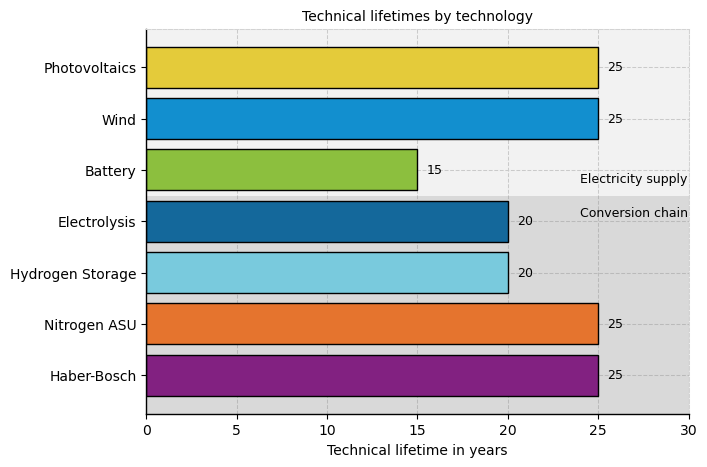

In [10]:
params = ["Haber-Bosch","Nitrogen ASU", "Hydrogen Storage","Electrolysis", "Battery", "Wind", "Photovoltaics"]
values = [Eingangsdaten["lebensdauer_hb"],Eingangsdaten["lebensdauer_asu"],Eingangsdaten["lebensdauer_h2s"],Eingangsdaten["lebensdauer_pem"],Eingangsdaten["lebensdauer_bat"], Eingangsdaten["lebensdauer_wkaon"],Eingangsdaten["lebensdauer_pv"]]
colors = [col_hb,col_asu,col_h2s,col_pem, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(3.5, 7, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 3.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(24, 3.75, "Electricity supply", fontsize=9, color="black")  
ax.text(24, 3.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(params, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.0f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Technical lifetime in years", fontsize=10)
plt.title("Technical lifetimes by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 30])

plt.savefig("Bilder/eingangsdaten_lebensdauer_bar.png", dpi=300, bbox_inches='tight')

##  1.2 Berechnung Annuitäten pro installierter Leistung/ Kapazität

In [11]:
annuity_pem = economics.annuity(Eingangsdaten["capex_pem"], Eingangsdaten["lebensdauer_pem"], Eingangsdaten["zinssatz_pem"])                            # €/ kW a 
annuity_pv = economics.annuity(Eingangsdaten["capex_pv"], Eingangsdaten["lebensdauer_pv"], Eingangsdaten["zinssatz_pv"])                                # €/ kW a
annuity_bat_leistung = economics.annuity(Eingangsdaten["capex_bat_leistung"], Eingangsdaten["lebensdauer_bat"], Eingangsdaten["zinssatz_bat"])          # €/ kW a
annuity_wkaon = economics.annuity(Eingangsdaten["capex_wkaon"], Eingangsdaten["lebensdauer_wkaon"], Eingangsdaten["zinssatz_wkaon"])                    # €/ kW a

annuity_bat_kapa = economics.annuity(Eingangsdaten["capex_bat_kapa"], Eingangsdaten["lebensdauer_bat"], Eingangsdaten["zinssatz_bat"])                  # €/ kWh a

annuity_h2s = economics.annuity(Eingangsdaten["capex_h2s"], Eingangsdaten["lebensdauer_h2s"], Eingangsdaten["zinssatz_h2s"])                            # € / kg a  --> jährliche Kosten pro gespeichertes kg
annuity_asu = economics.annuity(Eingangsdaten["capex_asu"], Eingangsdaten["lebensdauer_asu"], Eingangsdaten["zinssatz_asu"])                            # € h/ kg a
annuity_hb = economics.annuity(Eingangsdaten["capex_hb"], Eingangsdaten["lebensdauer_hb"], Eingangsdaten["zinssatz_hb"])                                # € h/ kg a


Ergebnisse_df.loc["annuity_pem", "Wert"] = annuity_pem
Ergebnisse_df.loc["annuity_pv", "Wert"] = annuity_pv
Ergebnisse_df.loc["annuity_bat_leistung", "Wert"] = annuity_bat_leistung
Ergebnisse_df.loc["annuity_wkaon", "Wert"] = annuity_wkaon
Ergebnisse_df.loc["annuity_bat_kapa", "Wert"] = annuity_bat_kapa
Ergebnisse_df.loc["annuity_h2s", "Wert"] = annuity_h2s
Ergebnisse_df.loc["annuity_asu", "Wert"] = annuity_asu
Ergebnisse_df.loc["annuity_hb", "Wert"] = annuity_hb


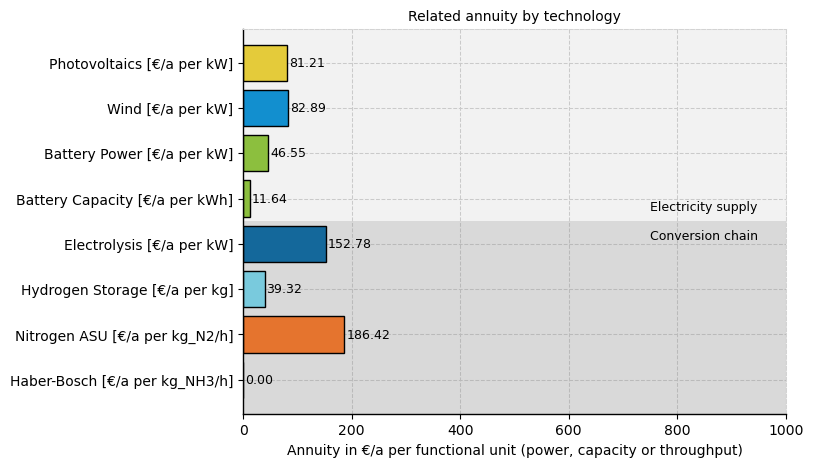

In [12]:
params = ["Haber-Bosch [€/a per kg_NH3/h]","Nitrogen ASU [€/a per kg_N2/h]", "Hydrogen Storage [€/a per kg]","Electrolysis [€/a per kW]", "Battery Capacity [€/a per kWh]", "Battery Power [€/a per kW]","Wind [€/a per kW]", "Photovoltaics [€/a per kW]"]
values = [annuity_hb, annuity_asu, annuity_h2s, annuity_pem, annuity_bat_kapa,annuity_bat_leistung, annuity_wkaon, annuity_pv ]
colors = [col_hb,col_asu,col_h2s,col_pem, col_bat,col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(3.5, 9, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 3.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(750, 3.75, "Electricity supply", fontsize=9, color="black")  
ax.text(750, 3.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(params, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Annuity in €/a per functional unit (power, capacity or throughput)", fontsize=10)
plt.title("Related annuity by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 1000])

plt.savefig("Bilder/eingangsdaten_annuity_bar.png", dpi=300, bbox_inches='tight')

# 2 Energiesystem 

In [13]:
zeit = pd.date_range('2023-01-01 00:00:00',
                     '2023-12-31 23:00:00',
                     freq='60min')
                     
energysystem = solph.EnergySystem(timeindex=zeit, infer_last_interval=True)

## 2.1 Busse

In [14]:
bus_el = solph.buses.Bus(label="Strom")                                           #Einheit: kWh
energysystem.add(bus_el)

bus_h2 = solph.buses.Bus(label="Wasserstoff")                                     #Einheit: kg
energysystem.add(bus_h2)

bus_nh3 = solph.buses.Bus(label="Ammoniak")                                       #Einheit: kg
energysystem.add(bus_nh3)

bus_n2 = solph.buses.Bus(label="Stickstoff")                                      #Einheit: kg
energysystem.add(bus_n2)

## 2.2 Quellen

In [15]:
energysystem.add(
    solph.components.Source(
        label="Wind",
        outputs={bus_el: 
                 solph.flows.Flow(fix=volllaststunden["Wind Patagonien"],                                                                                                                      # P/Pn = (%)
                                  nominal_value = solph.Investment(ep_costs = annuity_wkaon + Eingangsdaten["opex_fix_wkaon"] , maximum=Eingangsdaten["ausbaugrenze_wkaon"]),       # €/kWa + €/kWa     Grenze: kW
                                  variable_costs = Eingangsdaten["opex_var_wkaon"]                                                                                                  # €/kWh 
                                  )}))


energysystem.add(
    solph.components.Source(
        label="PV",
        outputs={bus_el: 
                 solph.flows.Flow(fix=volllaststunden["PV Patagonien"],                                                                                                                        # P/Pn = (%)
                                  nominal_value  = solph.Investment(ep_costs = annuity_pv +  Eingangsdaten["opex_fix_pv"] , maximum=Eingangsdaten["ausbaugrenze_pv"]),              # €/kWa + €/kWa     Grenze: kW
                                  variable_costs = Eingangsdaten["opex_var_pv"]                                                                                                     # €/kWh
                                  )}))
    

energysystem.add(
        solph.components.Source(
            label="Netzbezug",
            outputs={bus_el: 
                     solph.flows.Flow(variable_costs=Eingangsdaten["strompreis"])}))                                                                                                # €/kWh         
    

## 2.3 Senken

In [16]:
energysystem.add(
    solph.components.Sink(
        label="Verkauf_Strom", 
        inputs={bus_el: solph.flows.Flow(variable_costs=Eingangsdaten["stromerloes"])}))                 # - €/kWh


energysystem.add(
    solph.components.Sink(
        label="Verkauf_Wasserstoff", 
        inputs={bus_h2: solph.flows.Flow(variable_costs=Eingangsdaten["wasserstofferloes"])}))           # - €/kg


energysystem.add(
    solph.components.Sink(
        label="Verkauf_Ammoniak", 
        inputs={bus_nh3: solph.flows.Flow(variable_costs=Eingangsdaten["ammoniakerloes"])}))             # - €/kg

## 2.4 Konverter

In [17]:
energysystem.add(
    solph.components.Converter(
        label="elektrolyseur",
        inputs={bus_el: solph.flows.Flow(
            nominal_value=solph.Investment(ep_costs=annuity_pem + Eingangsdaten["capex_pem"]*Eingangsdaten["opex_pem"] ))},                                 # €/kWa + €/kW * %/a
        outputs={bus_h2: solph.flows.Flow()},
        conversion_factors={bus_el: Eingangsdaten["strombedarf_pem"], bus_h2: 1},                                                                           # kWh/kg_H2
       # non_convex=solph.NonConvex(maximum_uptime=60000),                                                                                                  # Lebensdauer Stack begrenzen
        ))                              


energysystem.add(
    solph.components.Converter(
        label="haber-bosch",                                                    
        inputs={
            bus_el: solph.flows.Flow(),
            bus_h2: solph.flows.Flow(),
            bus_n2: solph.flows.Flow()},         
        outputs={
            bus_nh3: solph.flows.Flow(fix=volllaststunden["Volllast"],                                                                                   # P/Pn = 1 
                                    nominal_value=Eingangsdaten["produktionskapa_hb"])},                                                                    # kg/h        
        conversion_factors={
            bus_el: Eingangsdaten["strombedarf_hb"] , bus_h2: Eingangsdaten["h2_bedarf_hb"] ,bus_n2: Eingangsdaten["n2_bedarf_hb"], bus_nh3: 1 },))         # kWh/kg_NH3, kg_H2/kg_NH3, kg_N2/kg_NH3


energysystem.add(
    solph.components.Converter(
        label="asu",
        inputs={bus_el: solph.flows.Flow(
            nominal_value=solph.Investment(ep_costs= annuity_asu/Eingangsdaten["strombedarf_asu"] + Eingangsdaten["capex_asu"]/Eingangsdaten["strombedarf_asu"] * Eingangsdaten["opex_asu"]))},                 # €*h/(kg*a) *kg/kWh + €*h/kg *kg/kWh * %/a = €h/kWha 
        outputs={bus_n2: solph.flows.Flow()},
        conversion_factors={bus_el: Eingangsdaten["strombedarf_asu"] , bus_n2: 1},))                                                                        # kWh/kg_N2

## 2.5 Speicher

In [18]:
wasserstofftank = solph.components.GenericStorage(                              
    nominal_storage_capacity=solph.Investment(ep_costs = annuity_h2s + Eingangsdaten["opex_h2s"] * Eingangsdaten["capex_h2s"]),               # €*h/(kg*a) + €*h/kg * %/a 
    label="h2s",
    inputs={bus_h2: solph.flows.Flow()},                
    outputs={bus_h2: solph.flows.Flow()},                         
    loss_rate=Eingangsdaten["verlustrate_h2s"] ,                                                                                              # %_Kapa/h 
    initial_storage_level=Eingangsdaten["fuellstand_h2s"] ,                                                                                   # %_Kapa
    inflow_conversion_factor=Eingangsdaten["eta_einspeichern_h2s"] ,                                                                          # %
    outflow_conversion_factor=Eingangsdaten["eta_ausspeichern_h2s"] ,                                                                         # %
    invest_relation_input_capacity = 1,                                                                                                       # legt abhängig von Kapazität Ein/Ausspeicherleistung fest / C-Rate
    invest_relation_output_capacity= 1,                                          
)

energysystem.add(wasserstofftank)
    
  
batterie = solph.components.GenericStorage(                              
    nominal_storage_capacity=solph.Investment(ep_costs=annuity_bat_kapa + Eingangsdaten["c_rate_bat"] * annuity_bat_leistung + Eingangsdaten["opex_fix_bat"]*Eingangsdaten["capex_bat_kapa"]),              # €/(kWh*a) + kw/kwh * €/(kW*a) =  €/(kWh*a)                             
    label="Batterie",
    inputs={bus_el: solph.flows.Flow()},                
    outputs={bus_el: solph.flows.Flow()},                         
    loss_rate = Eingangsdaten["verlustrate_bat"]/24,                                                                                        # %/d * d/24h = %/h
    initial_storage_level=Eingangsdaten["fuellstand_bat"] ,                                                                                 # %_Kapa
    inflow_conversion_factor=Eingangsdaten["eta_einspeichern_bat"] ,                                                                        # %
    outflow_conversion_factor= Eingangsdaten["eta_ausspeichern_bat"] ,                                                                      # %
    invest_relation_input_capacity = Eingangsdaten["c_rate_bat"],                                                                           # kW/kWh
    invest_relation_output_capacity= Eingangsdaten["c_rate_bat"],                                   
)

energysystem.add(batterie)


## 2.6 Modellauf

In [19]:
model = solph.Model(energysystem)
model.solve(solver='gurobi')
Ergebnisse = solph.processing.results(model)

# 3 Postprocessing

## 3.1 Auslesen der Ergebnisse

### 3.1.1 Busse

In [20]:
# Keine weitere extraktion, da selben ergebnisse wie unten bei Quellen, Konverter, Speicher und Senken
result_strombus = solph.views.node(Ergebnisse, 'Strom')
result_h2bus = solph.views.node(Ergebnisse, 'Wasserstoff')
result_n2bus = solph.views.node(Ergebnisse, 'Stickstoff')
result_nh3bus = solph.views.node(Ergebnisse, 'Ammoniak')

### 3.1.2 Quellen

In [21]:
result_strombezug = solph.views.node(Ergebnisse, 'Netzbezug')
result_strombezug_flow = result_strombezug['sequences'][(('Netzbezug', 'Strom'), 'flow')]   # kWh/h

result_wka = solph.views.node(Ergebnisse, 'Wind')
result_wka_invest = result_wka['scalars'][(('Wind', 'Strom'), 'invest')]                    # ? gleiche wie total
result_wka_leistung = result_wka['scalars'][(('Wind', 'Strom'), 'total')]                   # kW
result_wka_flow_generation = result_wka['sequences'][(('Wind', 'Strom'), 'flow')]           # kWh/h

result_pv = solph.views.node(Ergebnisse, 'PV')
result_pv_invest = result_pv['scalars'][(('PV', 'Strom'), 'invest')]                        # ? gleiche wie total
result_pv_leistung = result_pv['scalars'][(('PV', 'Strom'), 'total')]                       # kW
result_pv_flow_generation = result_pv['sequences'][(('PV', 'Strom'), 'flow')]               # kWh/h

Ergebnisse_df.loc["result_wka_leistung", "Wert"] = result_wka_leistung
Ergebnisse_df.loc["result_pv_leistung", "Wert"] = result_pv_leistung


### 3.1.3 Senken

In [22]:
result_stromverkauf = solph.views.node(Ergebnisse, 'Verkauf_Strom')
result_stromverkauf_flow = result_stromverkauf['sequences'][(('Strom', 'Verkauf_Strom'), 'flow')]             # kWh/h ?

result_h2verkauf = solph.views.node(Ergebnisse, 'Verkauf_Wasserstoff')
result_h2verkauf_flow = result_h2verkauf['sequences'][(('Wasserstoff', 'Verkauf_Wasserstoff'), 'flow')]       # kg_H2/h *8760h ?

result_nh3verkauf = solph.views.node(Ergebnisse, 'Verkauf_Ammoniak')
result_nh3verkauf_flow = result_nh3verkauf['sequences'][(('Ammoniak', 'Verkauf_Ammoniak'), 'flow')]           # kg_NH3/h *8760h ?

### 3.1.4 Konverter

In [23]:
result_pem = solph.views.node(Ergebnisse, 'elektrolyseur')
result_pem_invest = result_pem['scalars'][(('Strom', 'elektrolyseur'), 'invest')]                   # gleiche wie total
result_pem_leistung = result_pem['scalars'][(('Strom', 'elektrolyseur'), 'total')]                  # kW
result_pem_flow_elin = result_pem['sequences'][(('Strom', 'elektrolyseur'), 'flow')]                # kWh/h
result_pem_flow_h2out = result_pem['sequences'][(('elektrolyseur', 'Wasserstoff'), 'flow')]         # kg/h *8760h ?

result_asu = solph.views.node(Ergebnisse, 'asu')
result_asu_invest = result_asu['scalars'][(('Strom', 'asu'), 'invest')]                             # gleiche wie total
result_asu_leistung = result_asu['scalars'][(('Strom', 'asu'), 'total')]                            # kW
result_asu_flow_elin = result_asu['sequences'][(('Strom', 'asu'), 'flow')]                          # kWh/h
result_asu_flow_n2out = result_asu['sequences'][(('asu', 'Stickstoff'), 'flow')]                    # kg/h *8760h ?

result_hb = solph.views.node(Ergebnisse, 'haber-bosch')
result_hb_flow_n2in = result_hb['sequences'][(('Stickstoff', 'haber-bosch'), 'flow')]
result_hb_flow_h2in = result_hb['sequences'][(('Wasserstoff', 'haber-bosch'), 'flow')]
result_hb_flow_elin = result_hb['sequences'][(('Strom', 'haber-bosch'), 'flow')]
result_hb_flow_nh3out = result_hb['sequences'][(('haber-bosch', 'Ammoniak' ), 'flow')]


Ergebnisse_df.loc["result_pem_leistung", "Wert"] = result_pem_leistung
Ergebnisse_df.loc["result_asu_leistung", "Wert"] = result_asu_leistung

### 3.1.5 Speicher

In [24]:
result_h2s = solph.views.node(Ergebnisse, 'h2s')
result_h2s_invest = result_h2s['scalars'][(('Wasserstoff', 'h2s'), 'invest')]                           # ? gleiche wie total
result_h2s_kapa = result_h2s['scalars'][(('Wasserstoff', 'h2s'), 'total')]                              # kg/h
# noch öfter die selbe Zahl? wieso? worin liegen die unterschiede der Outputs?
result_h2s_initcontent = result_h2s['scalars'][(('h2s', 'None'), 'init_content')]                       # kg
result_h2s_flow_in = result_h2s['sequences'][(('Wasserstoff', 'h2s'), 'flow')]                          # kg/h *8760h ?
result_h2s_flow_out = result_h2s['sequences'][(('h2s', 'Wasserstoff'), 'flow')]                         # kg/h *8760h ?
result_h2s_flow_storagecontent = result_h2s['sequences'][(('h2s', 'None'), 'storage_content')]          # kg/h *8760h ?


result_bat = solph.views.node(Ergebnisse, 'Batterie')
result_bat_invest = result_bat['scalars'][(('Batterie', 'Strom'), 'invest')]                            # kW
result_bat_leistung = result_bat['scalars'][(('Batterie', 'Strom'), 'total')]                           # kW
result_bat_initcontent = result_bat['scalars'][(('Batterie', 'None'), 'init_content')]                  # kWh

result_bat_kapa = result_bat['scalars'][(('Batterie', 'None'), 'invest')]                               # kWh
#result_bat_leistung2 = result_bat['scalars'][(('Batterie', 'Strom'), 'total')]                         # kW
result_bat_flow_out = result_bat['sequences'][(('Batterie', 'Strom'), 'flow')]                          # kWh/h
result_bat_flow_in = result_bat['sequences'][(('Strom', 'Batterie'), 'flow')]                           # kWh/h
result_bat_flow_storagecontent = result_bat['sequences'][(('Batterie', 'None'), 'storage_content')]     # kWh/h ?


Ergebnisse_df.loc["result_h2s_kapa", "Wert"] = result_h2s_kapa
Ergebnisse_df.loc["result_bat_leistung", "Wert"] = result_bat_leistung
Ergebnisse_df.loc["result_bat_kapa", "Wert"] = result_bat_kapa

## 3.2 Darstellung der Ergebnisse

### 3.2.1 Darstellung der Scalars

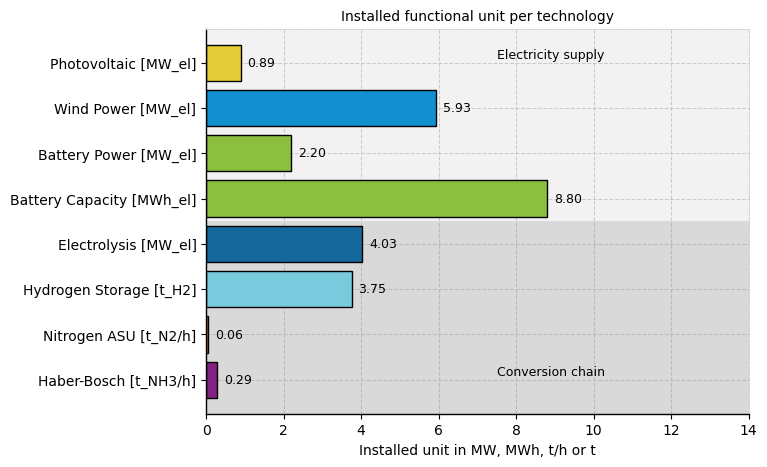

In [25]:
categories = ["Haber-Bosch [t_NH3/h]", "Nitrogen ASU [t_N2/h]", "Hydrogen Storage [t_H2]", "Electrolysis [MW_el]", "Battery Capacity [MWh_el]", "Battery Power [MW_el]", "Wind Power [MW_el]", "Photovoltaic [MW_el]"]
values = [Eingangsdaten['produktionskapa_hb'] / 1000, result_asu_leistung / 1000, result_h2s_kapa / 1000, result_pem_leistung / 1000, result_bat_kapa/1000, result_bat_leistung / 1000, result_wka_leistung / 1000, result_pv_leistung / 1000]
colors = [col_hb, col_asu, col_h2s, col_pem, col_bat, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

ax.axhspan(3.5, 8, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, 3.5, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(7.5, 7.1, "Electricity supply", fontsize=9, color="black")  
ax.text(7.5, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

# Zahlenwerte neben den Balken anzeigen
for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Installed unit in MW, MWh, t/h or t", fontsize=10)
plt.title("Installed functional unit per technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 14])

plt.savefig("Bilder/result_leistungen_bar.png", dpi=300, bbox_inches='tight')

### 3.2.2 Darstellung der Flows

In [26]:
startdatum = "2023-02-01 00:00:00"
enddatum = pd.to_datetime(startdatum) + pd.Timedelta(days=7) #immer einen Tag abzug da der letzte tag noch vollständig geplottet wird 60 Tage anzeigen --> days=59)
tickinterval = 15 # Abstand in Tagen zwischen den x Achsen Daten label

#### 3.2.2.1 Stromerzeugung und Bezug

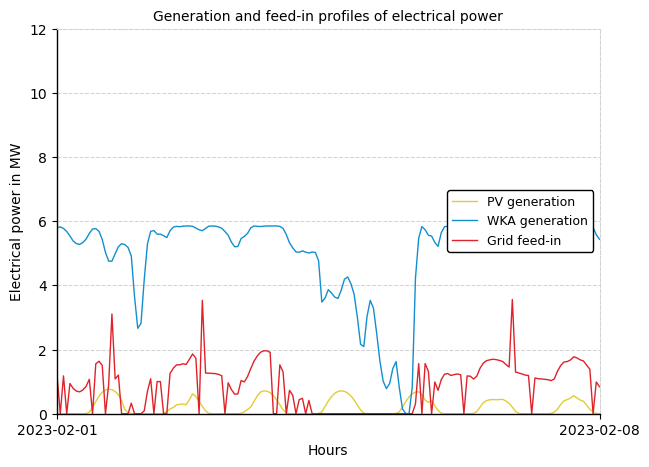

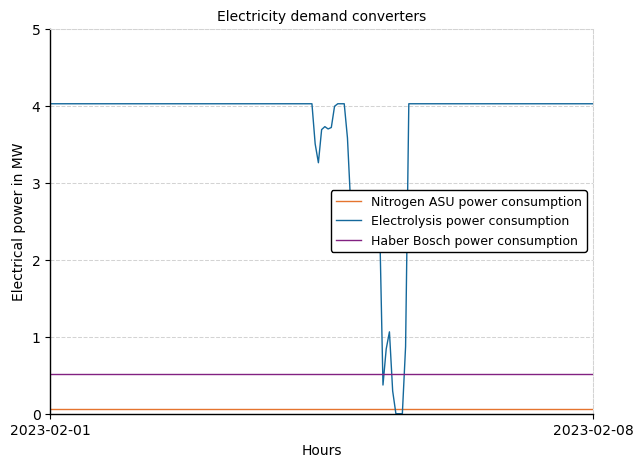

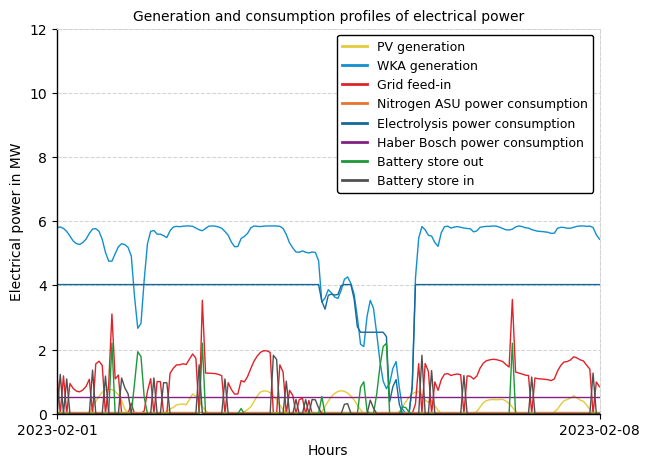

In [27]:
plt.figure(figsize=(7, 5))
plt.plot(result_pv_flow_generation[startdatum:enddatum]/1000, label="PV generation", color=col_pv, linewidth=1)
plt.plot(result_wka_flow_generation[startdatum:enddatum]/1000, label="WKA generation", color=col_wka, linewidth=1)
#plt.plot(result_strombezug_flow[startdatum:enddatum]/1000, label="Grid power supply", color=col_buy, linewidth=1)
plt.plot(result_stromverkauf_flow[startdatum:enddatum]/1000, label="Grid feed-in", color=col_sell, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 12)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Generation and feed-in profiles of electrical power", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Electrical power in MW", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='center right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_elektrisch_quellen_senken.png", dpi=300, bbox_inches='tight') 
plt.show()


##################################################################

plt.figure(figsize=(7, 5))
plt.plot(result_asu_flow_elin[startdatum:enddatum]/1000, label="Nitrogen ASU power consumption", color=col_asu, linewidth=1)
plt.plot(result_pem_flow_elin[startdatum:enddatum]/1000, label="Electrolysis power consumption", color=col_pem, linewidth=1)
plt.plot(result_hb_flow_elin[startdatum:enddatum]/1000, label="Haber Bosch power consumption", color=col_hb, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 5)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))



plt.title("Electricity demand converters", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Electrical power in MW", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='center right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_elektrisch_konverter.png", dpi=300, bbox_inches='tight')
plt.show()


###########################

plt.figure(figsize=(7, 5))
plt.plot(result_pv_flow_generation[startdatum:enddatum]/1000, label="PV generation", color=col_pv, linewidth=1)
plt.plot(result_wka_flow_generation[startdatum:enddatum]/1000, label="WKA generation", color=col_wka, linewidth=1)
plt.plot(result_stromverkauf_flow[startdatum:enddatum]/1000, label="Grid feed-in", color=col_sell, linewidth=1)
plt.plot(result_asu_flow_elin[startdatum:enddatum]/1000, label="Nitrogen ASU power consumption", color=col_asu, linewidth=1)
plt.plot(result_pem_flow_elin[startdatum:enddatum]/1000, label="Electrolysis power consumption", color=col_pem, linewidth=1)
plt.plot(result_hb_flow_elin[startdatum:enddatum]/1000, label="Haber Bosch power consumption", color=col_hb, linewidth=1)
plt.plot(result_bat_flow_out[startdatum:enddatum]/1000, label="Battery store out", color=col_chem, linewidth=1)
plt.plot(result_bat_flow_in[startdatum:enddatum]/1000, label="Battery store in", color=col_buy, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 12)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Generation and consumption profiles of electrical power", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Electrical power in MW", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
leg = plt.legend(loc='upper right', fontsize=9, frameon=True, 
                 edgecolor='black', facecolor='white', framealpha=1)

for line in leg.get_lines():
    line.set_linewidth(2)
plt.savefig("Bilder/result_flow_elektrisch_quellen_senken.png", dpi=300, bbox_inches='tight') 
plt.show()

#### 3.2.2.2 Batteriespeicher

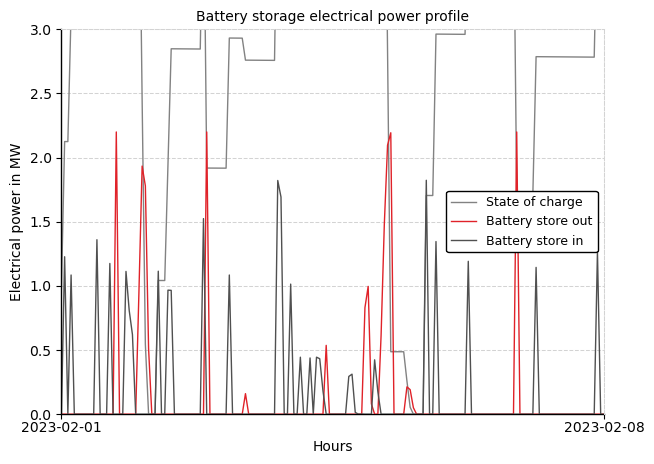

In [28]:
plt.figure(figsize=(7, 5))
plt.plot(result_bat_flow_storagecontent[startdatum:enddatum]/1000, label="State of charge", color=col_etc, linewidth=1)
plt.plot(result_bat_flow_out[startdatum:enddatum]/1000, label="Battery store out", color=col_sell, linewidth=1)
plt.plot(result_bat_flow_in[startdatum:enddatum]/1000, label="Battery store in", color=col_buy, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_zorder(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 3)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Battery storage electrical power profile", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Electrical power in MW", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)
plt.tick_params(axis='x', labelsize=10, rotation=0, pad=1)

plt.legend(loc='center right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_elektrisch_batterie.png", dpi=300, bbox_inches='tight')
plt.show()

#### 3.2.2.3 Wasserstoff

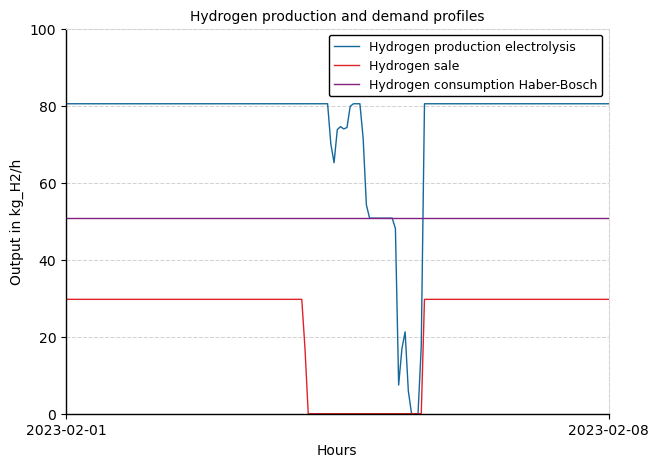

In [29]:
plt.figure(figsize=(7, 5))
plt.plot(result_pem_flow_h2out[startdatum:enddatum], label="Hydrogen production electrolysis", color=col_pem, linewidth=1)
plt.plot(result_h2verkauf_flow[startdatum:enddatum], label='Hydrogen sale', color=col_sell, linewidth=1)
plt.plot(result_hb_flow_h2in[startdatum:enddatum], label="Hydrogen consumption Haber-Bosch", color=col_hb, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
plt.ylim(0, 100)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Hydrogen production and demand profiles", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_H2/h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)
plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)
plt.savefig("Bilder/result_flow_wasserstoff.png", dpi=300, bbox_inches='tight')
plt.show()

#### 3.2.2.4 Wasserstoffspeicher

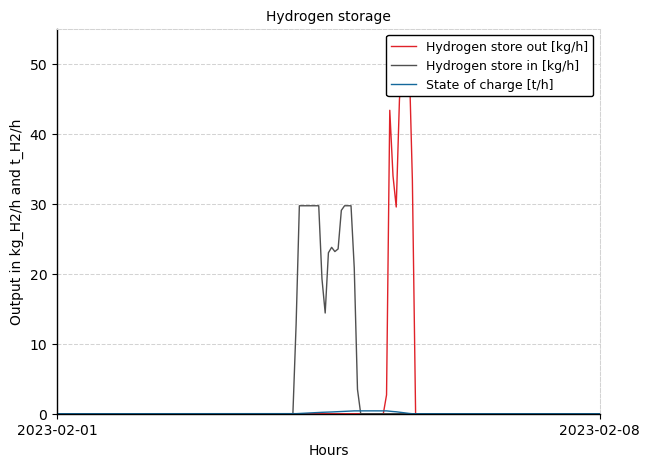

In [30]:
plt.figure(figsize=(7, 5))

plt.plot(result_h2s_flow_out[startdatum:enddatum], label="Hydrogen store out [kg/h]", color=col_sell, linewidth=1)
plt.plot(result_h2s_flow_in[startdatum:enddatum], label="Hydrogen store in [kg/h]", color=col_buy, linewidth=1)
plt.plot(result_h2s_flow_storagecontent[startdatum:enddatum]/1000, label="State of charge [t/h]", color=col_h2, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
#ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(0, 55)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Hydrogen storage", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_H2/h and t_H2/h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_wasserstoff_speicher.png", dpi=300, bbox_inches='tight')

plt.show()

#### 3.2.2.5 Ammoniak

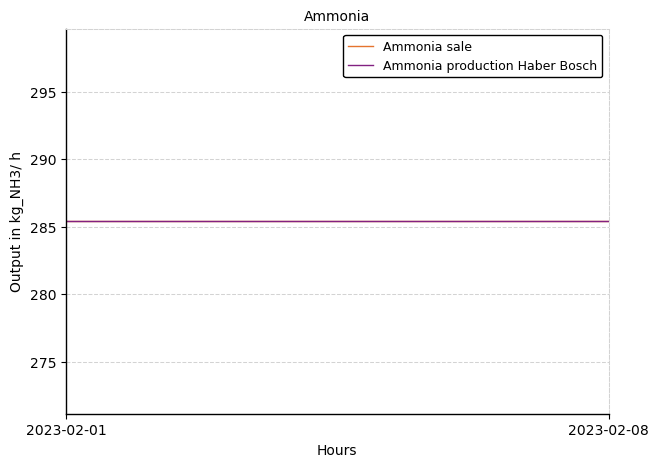

In [31]:
plt.figure(figsize=(7, 5))
plt.plot(result_nh3verkauf_flow[startdatum:enddatum], label="Ammonia sale", color=col_n2, linewidth=1)
plt.plot(result_hb_flow_nh3out[startdatum:enddatum], label="Ammonia production Haber Bosch", color=col_hb, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
#plt.ylim(0, 55)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Ammonia", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_NH3/ h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_ammoniak.png", dpi=300, bbox_inches='tight') 

plt.show()

#### 3.2.2.6 Stickstoff

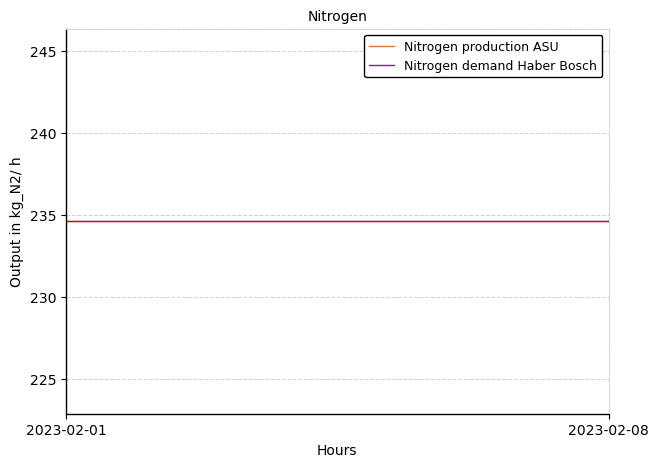

In [32]:
plt.figure(figsize=(7, 5))
plt.plot(result_asu_flow_n2out[startdatum:enddatum], label="Nitrogen production ASU", color=col_asu, linewidth=1)
plt.plot(result_hb_flow_n2in[startdatum:enddatum], label="Nitrogen demand Haber Bosch", color=col_hb, linewidth=1)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_axisbelow(True)
#plt.ylim(0, 55)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=tickinterval))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title("Nitrogen", fontsize=10)
plt.xlabel("Hours", fontsize=10)
plt.ylabel("Output in kg_N2/ h", fontsize=10)

plt.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='both', labelsize=10)

plt.legend(loc='upper right', fontsize=9, frameon=True, edgecolor='black', facecolor='white',framealpha=1)

plt.savefig("Bilder/result_flow_nitrogen.png", dpi=300, bbox_inches='tight') 

plt.show()

# 4 Berechnungen

## 4.1 Flow Summen

### 4.1.1 Elektrische Energie in kWh/a

In [33]:
# Quellen
result_strombezug_flowsum = result_strombezug_flow.sum()
result_wka_flowsum_generation = result_wka_flow_generation.sum()
result_pv_flowsum_generation = result_pv_flow_generation.sum()

Ergebnisse_df.loc["result_strombezug_flowsum", "Wert"] = result_strombezug_flowsum / 1000
Ergebnisse_df.loc["result_wka_flowsum_generation", "Wert"] = result_wka_flowsum_generation / 1000
Ergebnisse_df.loc["result_pv_flowsum_generation", "Wert"] = result_pv_flowsum_generation / 1000


# Konverter
result_pem_flowsum_elin = result_pem_flow_elin.sum()
result_asu_flowsum_elin = result_asu_flow_elin.sum()
result_hb_flowsum_elin = result_hb_flow_elin.sum()

Ergebnisse_df.loc["result_pem_flowsum_elin", "Wert"] = result_pem_flowsum_elin / 1000
Ergebnisse_df.loc["result_asu_flowsum_elin", "Wert"] = result_asu_flowsum_elin / 1000
Ergebnisse_df.loc["result_hb_flowsum_elin", "Wert"] = result_hb_flowsum_elin / 1000



# Speicher
result_bat_flowsum_out = result_bat_flow_out.sum()
result_bat_flowsum_in = result_bat_flow_in.sum()

Ergebnisse_df.loc["result_bat_flowsum_out", "Wert"] = result_bat_flowsum_out / 1000
Ergebnisse_df.loc["result_bat_flowsum_in", "Wert"] = result_bat_flowsum_in / 1000

calc_bat_loss = Eingangsdaten['fuellstand_bat'] * result_bat_leistung + result_bat_flowsum_in - result_bat_flowsum_out - result_bat_flow_storagecontent['2023-12-31 23:00:00']     # %_kapa * kWh + kWh - kWh - kWh


# Senken
result_stromverkauf_flowsum = result_stromverkauf_flow.sum()
Ergebnisse_df.loc["result_stromverkauf_flowsum", "Wert"] = result_stromverkauf_flowsum / 1000


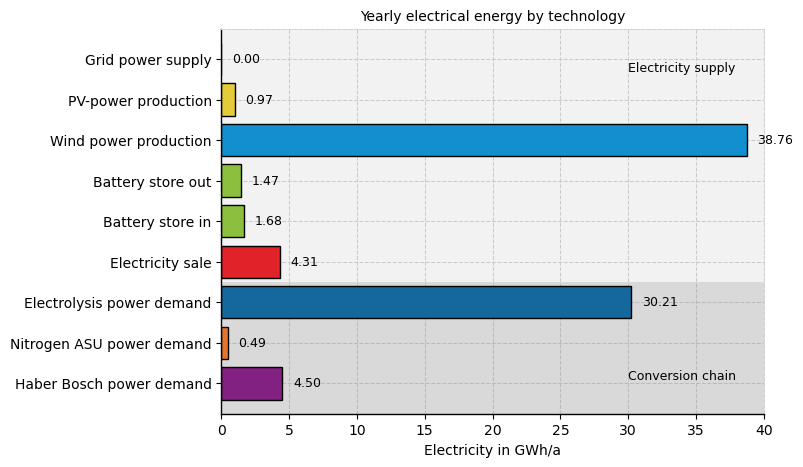

In [34]:
categories = [
"Haber Bosch power demand", "Nitrogen ASU power demand", "Electrolysis power demand",
"Electricity sale","Battery store in", "Battery store out",
"Wind power production", "PV-power production",
"Grid power supply"
]

values = [
result_hb_flowsum_elin / 1000000, result_asu_flowsum_elin / 1000000, result_pem_flowsum_elin / 1000000,
result_stromverkauf_flowsum / 1000000, result_bat_flowsum_in / 1000000, result_bat_flowsum_out / 1000000,
result_wka_flowsum_generation / 1000000, result_pv_flowsum_generation / 1000000,
result_strombezug_flowsum / 1000000
]

colors = [col_hb, col_asu, col_pem, col_sell, col_bat, col_bat, col_wka, col_pv, col_buy]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 2.5
ax.axhspan(cut, 9, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(30, 7.7, "Electricity supply", fontsize=9, color="black")  
ax.text(30, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Electricity in GWh/a", fontsize=10)
plt.title("Yearly electrical energy by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 40])

plt.savefig("Bilder/result_stromfluesse_bar.png", dpi=300, bbox_inches='tight')

### 4.1.2 Elektrische Energie Bilanz

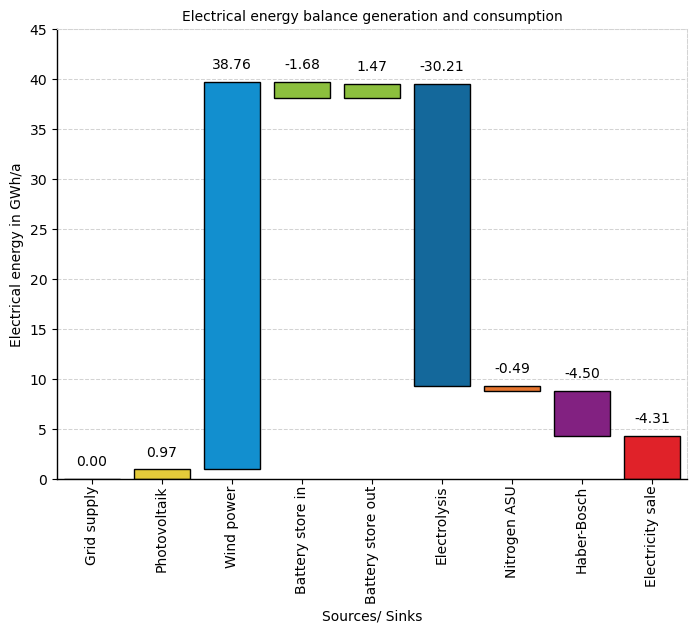

In [35]:
labels = ["Grid supply","Photovoltaik", "Wind power", "Battery store in", "Battery store out", "Electrolysis", "Nitrogen ASU", "Haber-Bosch", "Electricity sale" ]
colors = [col_buy, col_pv, col_wka , col_bat, col_bat, col_pem, col_asu, col_hb, col_sell]
values = [result_strombezug_flowsum/1000000,
          result_pv_flowsum_generation/1000000,
          result_wka_flowsum_generation/1000000,
          -result_bat_flowsum_in/1000000,
          result_bat_flowsum_out/1000000,
          -result_pem_flowsum_elin/1000000,
          -result_asu_flowsum_elin/1000000,
          -result_hb_flowsum_elin/1000000,
          -result_stromverkauf_flowsum/1000000
          ]

running_total = np.insert(np.cumsum(values), 0, 0)
start_points = running_total[:-1]

plt.figure(figsize=(7, 5))

ax = plt.gca()

# cut = 4.5
# ax.axvspan(-0.5, cut, facecolor=col_etc, alpha=0.1)   # Links
# ax.axvspan(cut, 8.5, facecolor=col_etc, alpha=0.3)    # Rechts
# ax.text(0.75, max(running_total) + 3, "Electricity supply", fontsize=9, color="black", ha='center')
# ax.text(7, max(running_total) + 3, "Conversion chain", fontsize=9, color="black", ha='center')


bars = plt.bar(labels, values, bottom=start_points, color=colors, edgecolor='black')

# Werte an die Balken hinzufügen (immer oberhalb)
for bar, value in zip(bars, values):
    height = bar.get_height()
    if value >= 0:
        # Für positive Werte oberhalb des Balkens
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)
    else:
        # Für negative Werte oberhalb des Balkens (trotz negativem Balken)
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)


ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(min(running_total), max(running_total) + 5)
plt.xlim(-0.5, 8.5)
plt.ylim(0, 45)

plt.title("Electrical energy balance generation and consumption", fontsize=10)
plt.ylabel("Electrical energy in GWh/a", fontsize=10)
plt.xlabel("Sources/ Sinks")

plt.grid(which='major', axis='y', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='x', labelsize=10, rotation=90, pad=1)
plt.tick_params(axis='y', labelsize=10, rotation=0)



plt.savefig("Bilder/calc_strombilanz_wasserfall.png", dpi=300, bbox_inches='tight')

plt.show()

### 4.1.3 Stoffmengen in kg/a

In [36]:
# Senken
result_h2verkauf_flowsum = result_h2verkauf_flow.sum()
result_nh3verkauf_flowsum = result_nh3verkauf_flow.sum()

Ergebnisse_df.loc["result_nh3verkauf_flowsum", "Wert"] = result_nh3verkauf_flowsum
Ergebnisse_df.loc["result_h2verkauf_flowsum", "Wert"] = result_h2verkauf_flowsum


# Speicher
result_h2s_flowsum_in = result_h2s_flow_in.sum()
result_h2s_flowsum_out = result_h2s_flow_out.sum()

Ergebnisse_df.loc["result_h2s_flowsum_in", "Wert"] = result_h2s_flowsum_in
Ergebnisse_df.loc["result_h2s_flowsum_out", "Wert"] = result_h2s_flowsum_out

#calc_h2s_loss = Eingangsdaten['fuellstand_h2s'] * result_h2s_kapa + result_h2s_flowsum_in - result_h2s_flowsum_out - result_h2s_flow_storagecontent['2023-12-31 23:00:00']     # %_kapa * kg + kg - kg - kg


# Konverter
result_pem_flowsum_h2out = result_pem_flow_h2out.sum()
result_asu_flowsum_n2out = result_asu_flow_n2out.sum()
result_hb_flowsum_nh3out = result_hb_flow_nh3out.sum()
result_hb_flowsum_h2in = result_hb_flow_h2in.sum()
result_hb_flowsum_n2in = result_hb_flow_n2in.sum()

Ergebnisse_df.loc["result_pem_flowsum_h2out", "Wert"] = result_pem_flowsum_h2out
Ergebnisse_df.loc["result_asu_flowsum_n2out", "Wert"] = result_asu_flowsum_n2out
Ergebnisse_df.loc["result_hb_flowsum_nh3out", "Wert"] = result_hb_flowsum_nh3out
Ergebnisse_df.loc["result_hb_flowsum_h2in", "Wert"] = result_hb_flowsum_h2in
Ergebnisse_df.loc["result_hb_flowsum_n2in", "Wert"] = result_hb_flowsum_n2in


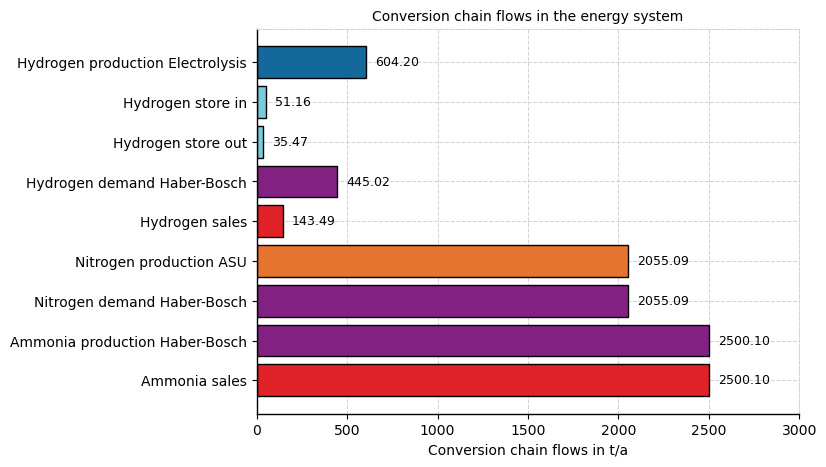

In [37]:
categories = [
    "Ammonia sales",
    "Ammonia production Haber-Bosch",
    "Nitrogen demand Haber-Bosch",
    "Nitrogen production ASU",
    "Hydrogen sales",
    "Hydrogen demand Haber-Bosch",
    "Hydrogen store out",
    "Hydrogen store in",
    "Hydrogen production Electrolysis"
]

values = [
    result_nh3verkauf_flowsum / 1000,             
    result_hb_flowsum_nh3out / 1000,                
    result_hb_flowsum_n2in / 1000,                  
    result_asu_flowsum_n2out / 1000,                
    result_h2verkauf_flowsum / 1000,                
    result_hb_flowsum_h2in / 1000,                  
    result_h2s_flowsum_out / 1000,                  
    result_h2s_flowsum_in / 1000,                   
    result_pem_flowsum_h2out / 1000
]                 

colors = [col_sell,col_hb,col_hb,col_asu,col_sell,col_hb,col_h2s,col_h2s,col_pem]


fig, ax = plt.subplots(figsize=(7, 5))

# ax.axhspan(-0.75, 9, facecolor=col_etc, alpha=0.3)
# ax.set_ylim([-0.75, len(values)-0.25])


bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Conversion chain flows in t/a", fontsize=10)
plt.title("Conversion chain flows in the energy system", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 3000])

plt.savefig("Bilder/result_massenstroeme_bar.png", dpi=300, bbox_inches='tight')


### 4.1.4 Wasserstoff Bilanz

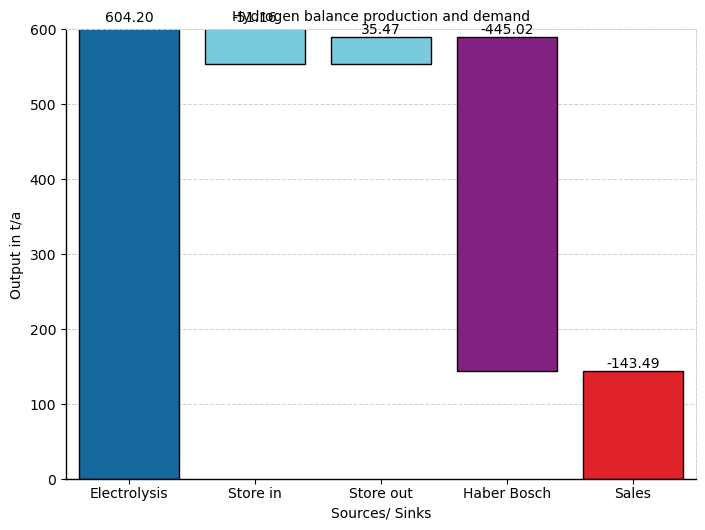

In [38]:
labels = ["Electrolysis","Store in", "Store out", "Haber Bosch", "Sales" ]
colors = [col_pem, col_h2s, col_h2s , col_hb, col_sell]
values = [result_pem_flowsum_h2out/1000, -result_h2s_flowsum_in/1000, result_h2s_flowsum_out/1000, -result_hb_flowsum_h2in/1000, -result_h2verkauf_flowsum/1000]

# Berechnungen für das Wasserfalldiagramm
running_total = np.insert(np.cumsum(values), 0, 0)
start_points = running_total[:-1]

plt.figure(figsize=(7, 5))

#ax.axhspan(0, 700, facecolor=col_etc)


bars = plt.bar(labels, values, bottom=start_points, color=colors, edgecolor='black')

# Werte an die Balken hinzufügen (immer oberhalb)
for bar, value in zip(bars, values):
    height = bar.get_height()
    if value >= 0:
        # Für positive Werte oberhalb des Balkens
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)
    else:
        # Für negative Werte oberhalb des Balkens (trotz negativem Balken)
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + 1, f'{value:.2f}', 
                 ha='center', va='bottom', fontsize=10)

ax = plt.gca()
#ax.axvspan(-0.75, 5, facecolor=col_etc, alpha=0.3)    # Rechts
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True)

plt.ylim(min(running_total), max(running_total) + max(running_total)*0.1 )
plt.xlim(-0.5, 4.5 )
plt.ylim(0, 600 )

plt.title("Hydrogen balance production and demand", fontsize=10)
plt.ylabel("Output in t/a", fontsize=10)
plt.xlabel("Sources/ Sinks")

plt.grid(which='major', axis='y', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='x', labelsize=10, rotation=0, pad=2)
plt.tick_params(axis='y', labelsize=10, rotation=0)

plt.savefig("Bilder/calc_h2bilanz_wasserfall.png", dpi=300, bbox_inches='tight')

plt.show()

## 4.2 Einnahmen und Aussgaben

### 4.2.1 Investitionssummen vor Verzinsung in Euro

In [39]:
calc_gesamtinvest_pem = Eingangsdaten["capex_pem"] * result_pem_leistung                                                                             # kW * €/kW = €
calc_gesamtinvest_wka = Eingangsdaten["capex_wkaon"] * result_wka_leistung                                                                           # kW * €/kW = €
calc_gesamtinvest_pv = Eingangsdaten["capex_pv"] * result_pv_leistung                                                                                # kW * €/kW = €
calc_gesamtinvest_bat = (Eingangsdaten["capex_bat_kapa"] / Eingangsdaten["c_rate_bat"] + Eingangsdaten["capex_bat_leistung"]) * result_bat_leistung  # (€/kWh *h  + €/kW ) *kW = €
calc_gesamtinvest_asu = Eingangsdaten["capex_asu"] * result_asu_leistung / Eingangsdaten["strombedarf_asu"]                                          # €/kg *h *kW * kg/kWh = €
calc_gesamtinvest_h2s = Eingangsdaten["capex_h2s"] * result_h2s_kapa                                                                                 # €/kg * kg = €
calc_gesamtinvest_hb = Eingangsdaten["capex_hb"] * Eingangsdaten["produktionskapa_hb"]                                                               # €/kg * h * kg/h = €

calc_gesamtinvest = calc_gesamtinvest_pem +calc_gesamtinvest_wka +calc_gesamtinvest_pv +calc_gesamtinvest_bat +calc_gesamtinvest_asu +calc_gesamtinvest_h2s +calc_gesamtinvest_hb 

Ergebnisse_df.loc["calc_gesamtinvest_pem", "Wert"] = calc_gesamtinvest_pem
Ergebnisse_df.loc["calc_gesamtinvest_wka", "Wert"] = calc_gesamtinvest_wka
Ergebnisse_df.loc["calc_gesamtinvest_pv", "Wert"] = calc_gesamtinvest_pv
Ergebnisse_df.loc["calc_gesamtinvest_bat", "Wert"] = calc_gesamtinvest_bat
Ergebnisse_df.loc["calc_gesamtinvest_asu", "Wert"] = calc_gesamtinvest_asu
Ergebnisse_df.loc["calc_gesamtinvest_h2s", "Wert"] = calc_gesamtinvest_h2s
Ergebnisse_df.loc["calc_gesamtinvest_hb", "Wert"] = calc_gesamtinvest_hb
Ergebnisse_df.loc["calc_gesamtinvest", "Wert"] = calc_gesamtinvest


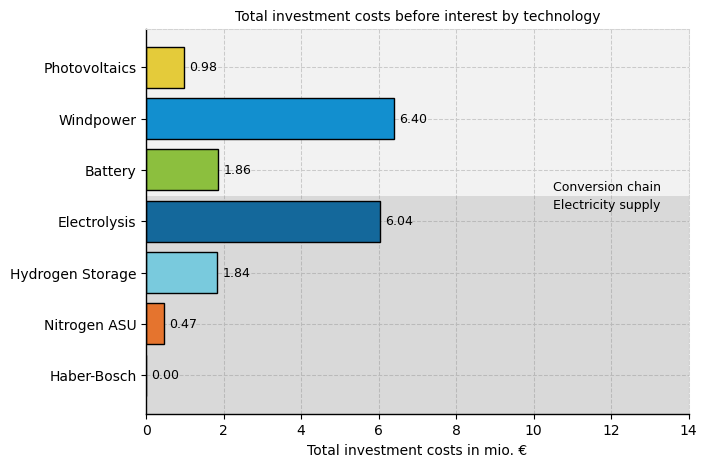

In [40]:
categories = ["Haber-Bosch", "Nitrogen ASU", "Hydrogen Storage", "Electrolysis", "Battery", "Windpower", "Photovoltaics"]
values = [
calc_gesamtinvest_hb / 1e6, calc_gesamtinvest_asu / 1e6, calc_gesamtinvest_h2s / 1e6,
calc_gesamtinvest_pem / 1e6, calc_gesamtinvest_bat / 1e6, calc_gesamtinvest_wka / 1e6,
calc_gesamtinvest_pv / 1e6
]
colors = [col_hb, col_asu, col_h2s, col_pem, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 3.5
ax.axhspan(cut, 7, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(10.5, cut-0.25, "Electricity supply", fontsize=9, color="black")  
ax.text(10.5, cut+0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Total investment costs in mio. €", fontsize=10)
plt.title("Total investment costs before interest by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 14])

plt.savefig("Bilder/calc_gesamtinvest_bar.png", dpi=300, bbox_inches='tight')

### 4.2.2 Annuitäten in €/a

In [41]:
calc_annuity_pem = result_pem_leistung * annuity_pem                                                                        # kW *  €/kWa = €/a
calc_annuity_wka = result_wka_leistung * annuity_wkaon                                                                      # kW *  €/kWa = €/a
calc_annuity_pv = result_pv_leistung * annuity_pv                                                                           # kW *  €/kWa = €/a
calc_annuity_asu = result_asu_leistung/ Eingangsdaten["strombedarf_asu"] * annuity_asu                                      # kW * kg/kWh €/a * h/kg = €/a
calc_annuity_h2s = result_h2s_kapa * annuity_h2s                                                                            # kg * €/kga * a = €/a
calc_annuity_hb = Eingangsdaten["produktionskapa_hb"] * annuity_hb                                                          # kg/h * €/a * h/kg  = €/a
calc_annuity_bat = (annuity_bat_kapa * result_bat_kapa + annuity_bat_leistung * result_bat_leistung )                       # (€/kWha * kWh ) + (€/kWa * kW ) = €/a

Ergebnisse_df.loc["calc_annuity_pem", "Wert"] = calc_annuity_pem
Ergebnisse_df.loc["calc_annuity_wka", "Wert"] = calc_annuity_wka
Ergebnisse_df.loc["calc_annuity_pv", "Wert"] = calc_annuity_pv
Ergebnisse_df.loc["calc_annuity_asu", "Wert"] = calc_annuity_asu
Ergebnisse_df.loc["calc_annuity_h2s", "Wert"] = calc_annuity_h2s
Ergebnisse_df.loc["calc_annuity_hb", "Wert"] = calc_annuity_hb
Ergebnisse_df.loc["calc_annuity_bat", "Wert"] = calc_annuity_bat

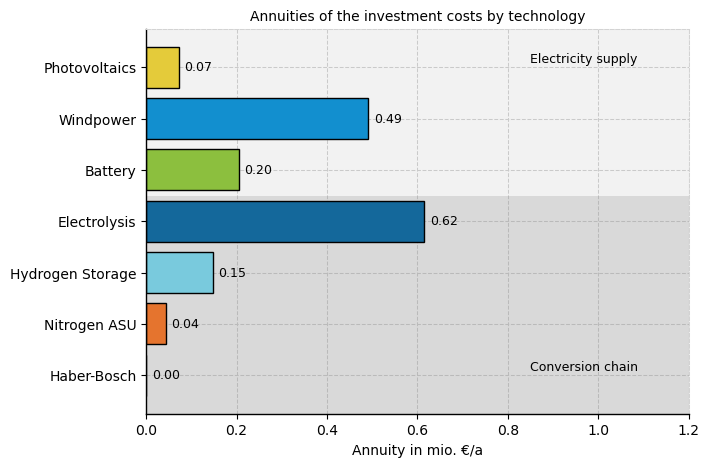

In [42]:
categories = ["Haber-Bosch", "Nitrogen ASU", "Hydrogen Storage", "Electrolysis", "Battery", "Windpower", "Photovoltaics"]
values = [
calc_annuity_hb / 1e6, calc_annuity_asu / 1e6, calc_annuity_h2s / 1e6,
calc_annuity_pem / 1e6, calc_annuity_bat / 1e6, calc_annuity_wka / 1e6,
calc_annuity_pv / 1e6
]
colors = [col_hb, col_asu, col_h2s, col_pem, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 3.5
ax.axhspan(cut, 8, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(0.85, 6.1, "Electricity supply", fontsize=9, color="black")  
ax.text(0.85, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02, 
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Annuity in mio. €/a", fontsize=10)
plt.title("Annuities of the investment costs by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 1.2])

plt.savefig("Bilder/calc_annuity_bar.png", dpi=300, bbox_inches='tight')

### 4.2.3 Investitionskosten Verzinst in €

In [43]:
calc_verzinstinvest_pem = calc_annuity_pem * Eingangsdaten["lebensdauer_pem"]                                                       # kW *  €/kWa * a = €
calc_verzinstinvest_wka = calc_annuity_wka * Eingangsdaten["lebensdauer_wkaon"]                                                     # kW *  €/kWa * a = €
calc_verzinstinvest_pv = calc_annuity_pv * Eingangsdaten["lebensdauer_pv"]                                                          # kW *  €/kWa * a = €
calc_verzinstinvest_asu = calc_annuity_asu * Eingangsdaten["lebensdauer_asu"]                                                       # kW * kg/kWh €/a * h/kg * a = €
calc_verzinstinvest_h2s = calc_annuity_h2s * Eingangsdaten["lebensdauer_h2s"]                                                       # kg * €/kga * a = €
calc_verzinstinvest_hb = calc_annuity_hb * Eingangsdaten["lebensdauer_hb"]                                                          # kg/h * €/a * h/kg * a = €
calc_verzinstinvest_bat = calc_annuity_bat * Eingangsdaten["lebensdauer_bat"]                                                       # (€/kWha * kWh * a) + (€/kWa * kW * a) = €

calc_verzinstinvest_gesamt = calc_verzinstinvest_pem + calc_verzinstinvest_wka + calc_verzinstinvest_pv + calc_verzinstinvest_asu + calc_verzinstinvest_h2s + calc_verzinstinvest_hb + calc_verzinstinvest_bat

Ergebnisse_df.loc["calc_verzinstinvest_pem", "Wert"] = calc_verzinstinvest_pem
Ergebnisse_df.loc["calc_verzinstinvest_wka", "Wert"] = calc_verzinstinvest_wka
Ergebnisse_df.loc["calc_verzinstinvest_pv", "Wert"] = calc_verzinstinvest_pv
Ergebnisse_df.loc["calc_verzinstinvest_bat", "Wert"] = calc_verzinstinvest_bat
Ergebnisse_df.loc["calc_verzinstinvest_asu", "Wert"] = calc_verzinstinvest_asu
Ergebnisse_df.loc["calc_verzinstinvest_h2s", "Wert"] = calc_verzinstinvest_h2s
Ergebnisse_df.loc["calc_verzinstinvest_hb", "Wert"] = calc_verzinstinvest_hb

Ergebnisse_df.loc["calc_verzinstinvest_gesamt", "Wert"] = calc_verzinstinvest_gesamt


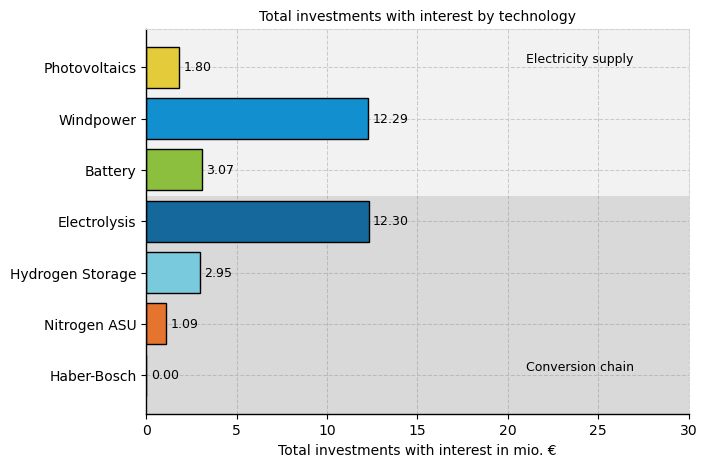

In [44]:
categories = ["Haber-Bosch", "Nitrogen ASU", "Hydrogen Storage", "Electrolysis", "Battery", "Windpower", "Photovoltaics"]
values = [
calc_verzinstinvest_hb / 1e6, calc_verzinstinvest_asu / 1e6, calc_verzinstinvest_h2s / 1e6,
calc_verzinstinvest_pem / 1e6, calc_verzinstinvest_bat / 1e6, calc_verzinstinvest_wka / 1e6,
calc_verzinstinvest_pv / 1e6
]
colors = [col_hb, col_asu, col_h2s, col_pem, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 3.5
ax.axhspan(cut, 7, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(21, 6.1, "Electricity supply", fontsize=9, color="black")  
ax.text(21, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Total investments with interest in mio. €", fontsize=10)
plt.title("Total investments with interest by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_xlim([0, 30])

plt.savefig("Bilder/calc_verzinstinvest_bar.png", dpi=300, bbox_inches='tight')

### 4.2.4 Einnahmen in €/a

In [45]:
calc_einnahmen_stromverkauf = result_stromverkauf_flowsum * Eingangsdaten["stromerloes"] *-1
calc_einnahmen_h2verkauf = result_h2verkauf_flowsum * Eingangsdaten["wasserstofferloes"] * -1               # kg/a * €/kg = €/a
calc_einnahmen_nh3verkauf = result_nh3verkauf_flowsum * Eingangsdaten["ammoniakerloes"] * -1                # kg/a * €/kg = €/a

Ergebnisse_df.loc["calc_einnahmen_stromverkauf", "Wert"] = calc_einnahmen_stromverkauf
Ergebnisse_df.loc["calc_einnahmen_h2verkauf", "Wert"] = calc_einnahmen_h2verkauf
Ergebnisse_df.loc["calc_einnahmen_nh3verkauf", "Wert"] = calc_einnahmen_nh3verkauf

### 4.2.5 Betriebskosten OPEX in €/a

In [46]:
calc_strombezug_kosten = result_strombezug_flowsum * Eingangsdaten["strompreis"]                                                              # kWh/a * €/kWh = €/a
calc_opex_fix_wkaon = result_wka_leistung * Eingangsdaten["opex_fix_wkaon"]                                                                   # kW * €/kWa = €/a    
calc_opex_fix_pv = result_pv_leistung * Eingangsdaten["opex_fix_pv"]                                                                          # kW * €/kWa = €/a
calc_opex_fix_bat = result_bat_leistung * Eingangsdaten["opex_fix_bat"] * Eingangsdaten["capex_bat_leistung"]                                 # kW * %/a * €/kW = €/a
calc_opex_fix_pem = result_pem_leistung * Eingangsdaten["opex_pem"] * Eingangsdaten["capex_pem"]                                              # kW * %/a * €/kW = €/a
calc_opex_fix_asu = result_asu_leistung/ Eingangsdaten["strombedarf_asu"] * Eingangsdaten["opex_asu"] * Eingangsdaten["capex_asu"]            # kW * kg/kWh * %/a * (€/kg * h) = €/a
calc_opex_fix_h2s = result_h2s_kapa * Eingangsdaten["opex_h2s"] * Eingangsdaten["capex_h2s"]                                                  # kg/h * %/a * €/kg *h = €/a
calc_opex_fix_hb = Eingangsdaten['produktionskapa_hb'] * Eingangsdaten['opex_hb'] #* Eingangsdaten['capex_hb']                                  # kg/h * %/a * €/kg * h = €/a
calc_opex_var_wkaon = Eingangsdaten["opex_var_wkaon"] * result_wka_flowsum_generation                                                         # €/kWh * kWh/a = €/a
calc_opex_var_pv = Eingangsdaten["opex_var_pv"] * result_pv_flowsum_generation                                                                # €/kWh * kWh/a = €/a
calc_opex_gesamt = calc_strombezug_kosten + calc_opex_fix_wkaon + calc_opex_fix_pv + calc_opex_fix_bat + calc_opex_fix_pem + calc_opex_fix_asu + calc_opex_fix_h2s + calc_opex_fix_hb + calc_opex_var_wkaon + calc_opex_var_pv  # €/a


Ergebnisse_df.loc["calc_strombezug_kosten", "Wert"] = calc_strombezug_kosten
Ergebnisse_df.loc["calc_opex_fix_wkaon", "Wert"] = calc_opex_fix_wkaon
Ergebnisse_df.loc["calc_opex_fix_pv", "Wert"] = calc_opex_fix_pv
Ergebnisse_df.loc["calc_opex_fix_bat", "Wert"] = calc_opex_fix_bat
Ergebnisse_df.loc["calc_opex_fix_pem", "Wert"] = calc_opex_fix_pem
Ergebnisse_df.loc["calc_opex_fix_asu", "Wert"] = calc_opex_fix_asu
Ergebnisse_df.loc["calc_opex_fix_h2s", "Wert"] = calc_opex_fix_h2s
Ergebnisse_df.loc["calc_opex_fix_hb", "Wert"] = calc_opex_fix_hb
Ergebnisse_df.loc["calc_opex_var_wkaon", "Wert"] = calc_opex_var_wkaon
Ergebnisse_df.loc["calc_opex_var_pv", "Wert"] = calc_opex_var_pv
Ergebnisse_df.loc["calc_opex_gesamt", "Wert"] = calc_opex_gesamt


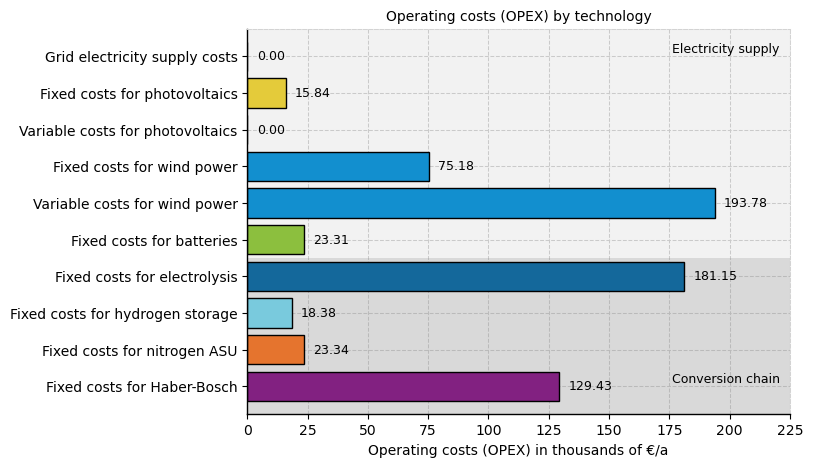

In [47]:

categories = [
"Fixed costs for Haber-Bosch", "Fixed costs for nitrogen ASU", "Fixed costs for hydrogen storage", "Fixed costs for electrolysis",
"Fixed costs for batteries", "Variable costs for wind power", "Fixed costs for wind power",
"Variable costs for photovoltaics", "Fixed costs for photovoltaics", "Grid electricity supply costs"
]
values = [
calc_opex_fix_hb / 1e3, calc_opex_fix_asu / 1e3, calc_opex_fix_h2s / 1e3, calc_opex_fix_pem / 1e3,
calc_opex_fix_bat / 1e3, calc_opex_var_wkaon / 1e3, calc_opex_fix_wkaon / 1e3,
calc_opex_var_pv / 1e3, calc_opex_fix_pv / 1e3, calc_strombezug_kosten / 1e3
]
colors = [col_hb, col_asu, col_h2s, col_pem, col_bat, col_wka, col_wka, col_pv, col_pv, col_buy]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 3.5
ax.axhspan(cut, 10, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(176, 9.1, "Electricity supply", fontsize=9, color="black")  
ax.text(176, 0.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Operating costs (OPEX) in thousands of €/a", fontsize=10)
plt.title("Operating costs (OPEX) by technology", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,225)

plt.savefig("Bilder/calc_opex_bar.png", dpi=300, bbox_inches='tight')

## 4.3 Finanzielle Bilanzierung

### 4.3.1 Gesamtkosten pro Technologie und Jahr

In [48]:
calc_cost_pv = annuity_pv*result_pv_leistung + calc_opex_fix_pv + calc_opex_var_pv                      # €/kWa * kW + €/a + €/a = €/a
calc_cost_wkaon = annuity_wkaon * result_wka_leistung + calc_opex_fix_wkaon + calc_opex_var_wkaon       # "
calc_cost_pem = annuity_pem * result_pem_leistung + calc_opex_fix_pem
calc_cost_hb = annuity_hb * Eingangsdaten['produktionskapa_hb'] + calc_opex_fix_hb
calc_cost_asu = annuity_asu * result_asu_leistung/Eingangsdaten['strombedarf_asu'] + calc_opex_fix_asu
calc_cost_h2s = annuity_h2s * result_h2s_kapa + calc_opex_fix_h2s                                                       # €/a * h/kg * kg/h = €/a
calc_cost_bat = annuity_bat_kapa * result_bat_kapa + annuity_bat_leistung * result_bat_leistung + calc_opex_fix_bat

calc_cost_gesamt = calc_cost_asu + calc_cost_bat + calc_cost_h2s + calc_cost_hb + calc_cost_pem + calc_cost_wkaon + calc_cost_pv + calc_strombezug_kosten

Ergebnisse_df.loc["calc_cost_pv", "Wert"] = calc_cost_pv
Ergebnisse_df.loc["calc_cost_wkaon", "Wert"] = calc_cost_wkaon
Ergebnisse_df.loc["calc_cost_pem", "Wert"] = calc_cost_pem
Ergebnisse_df.loc["calc_cost_hb", "Wert"] = calc_cost_hb
Ergebnisse_df.loc["calc_cost_asu", "Wert"] = calc_cost_asu
Ergebnisse_df.loc["calc_cost_h2s", "Wert"] = calc_cost_h2s
Ergebnisse_df.loc["calc_cost_bat", "Wert"] = calc_cost_bat
Ergebnisse_df.loc["calc_cost_gesamt", "Wert"] = calc_cost_gesamt


### 4.3.1 Berechnung Bilanz

In [49]:
calc_einnahmen_gesamt = calc_einnahmen_h2verkauf + calc_einnahmen_nh3verkauf +  calc_einnahmen_stromverkauf

calc_verzinstinvest_annuity_gesamt = (annuity_wkaon*result_wka_leistung
                                      + annuity_pv*result_pv_leistung
                                      + annuity_pem*result_pem_leistung
                                      + annuity_h2s*result_h2s_kapa
                                      + annuity_asu*result_asu_leistung/ Eingangsdaten["strombedarf_asu"]                   #€h/kga * kW * kg/kWh = €/a
                                      + annuity_hb*Eingangsdaten["produktionskapa_hb"]
                                      + result_bat_leistung * annuity_bat_leistung + result_bat_kapa*annuity_bat_kapa
)

calc_ausgaben_gesamt = calc_opex_gesamt + calc_verzinstinvest_annuity_gesamt

calc_GuV = calc_einnahmen_gesamt - calc_ausgaben_gesamt



Ergebnisse_df.loc["calc_einnahmen_gesamt", "Wert"] = calc_einnahmen_gesamt
Ergebnisse_df.loc["calc_verzinstinvest_annuity_gesamt", "Wert"] = calc_verzinstinvest_annuity_gesamt
Ergebnisse_df.loc["calc_ausgaben_gesamt", "Wert"] = calc_ausgaben_gesamt
Ergebnisse_df.loc["calc_GuV", "Wert"] = calc_GuV



### 4.3.2 Darstellung

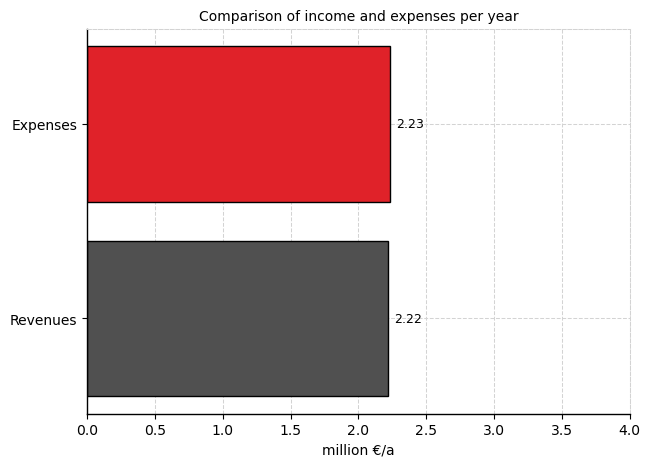

In [50]:
categories = ["Revenues", "Expenses"]
values = [calc_einnahmen_gesamt/1000000, calc_ausgaben_gesamt/1000000]
colors = [col_buy, col_sell]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("million €/a", fontsize=10)
plt.title("Comparison of income and expenses per year", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,4)

plt.savefig("Bilder/calc_eurobilanz_bar.png", dpi=300, bbox_inches='tight')

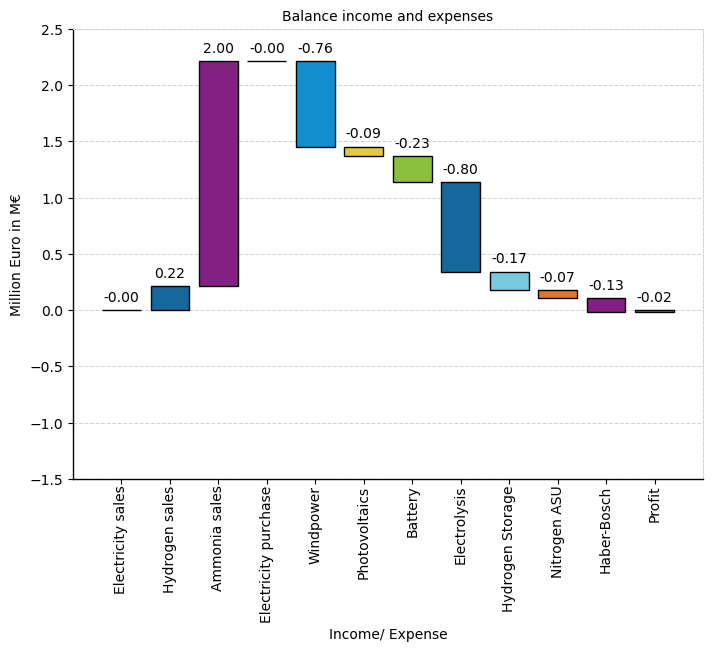

In [51]:
labels = ['Electricity sales', 'Hydrogen sales', 'Ammonia sales', 'Electricity purchase', 'Windpower', 'Photovoltaics','Battery', 'Electrolysis','Hydrogen Storage', 'Nitrogen ASU',  'Haber-Bosch', 'Profit']
colors = [col_sell, col_h2, col_nh3, col_buy, col_wka, col_pv, col_bat, col_pem, col_h2s, col_asu, col_hb, col_etc]
values = [calc_einnahmen_stromverkauf/1000000,
            calc_einnahmen_h2verkauf/1000000,
            calc_einnahmen_nh3verkauf/1000000,
            -calc_strombezug_kosten/1000000,
            -calc_opex_fix_wkaon/1000000-calc_opex_var_wkaon/1000000-annuity_wkaon/1000000*result_wka_leistung,
            -calc_opex_fix_pv/1000000-calc_opex_var_pv/1000000-annuity_pv/1000000*result_pv_leistung,
            -calc_opex_fix_bat/1000000-result_bat_leistung * annuity_bat_leistung/1000000 - result_bat_kapa*annuity_bat_kapa/1000000,
            -calc_opex_fix_pem/1000000-annuity_pem/1000000*result_pem_leistung,
            -calc_opex_fix_h2s/1000000-annuity_h2s/1000000*result_h2s_kapa,
            -calc_opex_fix_asu/1000000-annuity_asu/1000000*result_asu_leistung/ Eingangsdaten["strombedarf_asu"],
            -calc_opex_fix_hb/1000000-annuity_hb/1000000*Eingangsdaten["produktionskapa_hb"],
            -calc_GuV/1000000
            ]

running_total = np.insert(np.cumsum(values), 0, 0)
start_points = running_total[:-1]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, bottom=start_points, color=colors, edgecolor='black')

for bar, value, label in zip(bars, values, labels):
    height = bar.get_height()
    #display_value = abs(value) if label == "Profit" else value  # Gewinn als positiv anzeigen
    display_value = -abs(value) if label == "Profit" else value
    #display_value = value
    if value >= 0:
        # Für positive Werte oberhalb des Balkens
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height + 0.05, f'{display_value:.2f}', 
                 ha='center', va='bottom', fontsize=10)
    else:
        # Für negative Werte oberhalb des Balkens (trotz negativem Balken)
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + 0.05, f'{display_value:.2f}', 
                 ha='center', va='bottom', fontsize=10)

ax = plt.gca()
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

plt.margins(0)
ax.margins(0)
ax.set_position([0.05, 0.05, 0.9, 0.9])
ax.set_axisbelow(True) 

plt.ylim(-1.5, 2.5)
plt.xlim(-1, 12)

plt.title("Balance income and expenses", fontsize=10)
plt.ylabel("Million Euro in M€", fontsize=10)
plt.xlabel("Income/ Expense")

plt.grid(which='major', axis='y', linestyle='--', linewidth=0.75, color='lightgray')
plt.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.tick_params(axis='x', labelsize=10, rotation=90, pad=1)
plt.tick_params(axis='y', labelsize=10, rotation=0)

plt.savefig("Bilder/calc_EuroBilanz_wasserfall.png", dpi=300, bbox_inches='tight')

plt.show()


## 4.4 Gestehungskosten

### 4.4.1 Levelized Cost of Wind and PV

In [52]:
calc_ucrf_wka = (Eingangsdaten["zinssatz_wkaon"]*(1+Eingangsdaten["zinssatz_wkaon"])**Eingangsdaten["lebensdauer_wkaon"])/((1+Eingangsdaten["zinssatz_wkaon"])**Eingangsdaten["lebensdauer_wkaon"]-1)
if result_wka_flowsum_generation >0:
    calc_lcoe_wka = (calc_gesamtinvest_wka * calc_ucrf_wka + calc_opex_fix_wkaon)/result_wka_flowsum_generation + Eingangsdaten["opex_var_wkaon"]                                                               # (€ * %/a + €/a) * a/kWh + €/kWh = €/KWh
else: calc_lcoe_wka = 0
print("Levelized Cost of Electricity (Wind): ", f"{calc_lcoe_wka*100:.2f}", "ct/kWh")                                                                                                                       # Die Stromgestehungskosten von Onshore-Windenergieanlagen(WEA) liegen im Jahr 2024 zwischen 4,3 und 9,2 €Cent/kWh
Ergebnisse_df.loc["calc_lcoe_wka", "Wert"] = calc_lcoe_wka*100

Levelized Cost of Electricity (Wind):  1.96 ct/kWh


In [53]:
calc_ucrf_pv = (Eingangsdaten["zinssatz_pv"]*(1+Eingangsdaten["zinssatz_pv"])**Eingangsdaten["lebensdauer_pv"])/((1+Eingangsdaten["zinssatz_pv"])**Eingangsdaten["lebensdauer_pv"]-1)
if result_pv_flowsum_generation >0:
    calc_lcoe_pv = (calc_gesamtinvest_pv * calc_ucrf_pv + calc_opex_fix_pv)/result_pv_flowsum_generation + Eingangsdaten["opex_var_pv"]                                                               # (€ * %/a + €/a) * a/kWh + €/kWh = €/KWh
else: calc_lcoe_pv = 0
print("Levelized Cost of Electricity (PV): ", f"{calc_lcoe_pv*100:.2f}", "ct/kWh")                                                                                                                # Stromgestehungskosten von PV-Anlagen je nach Anlagentyp und Sonneneinstrahlung zwischen 4,1 und 14,4 €Cent/kWh variieren
Ergebnisse_df.loc["calc_lcoe_pv", "Wert"] = calc_lcoe_pv*100

Levelized Cost of Electricity (PV):  9.05 ct/kWh


### 4.4.2 Levelized Cost of Battery

In [54]:
calc_ucrf_bat = (Eingangsdaten["zinssatz_bat"]*(1+Eingangsdaten["zinssatz_bat"])**Eingangsdaten["lebensdauer_bat"])/((1+Eingangsdaten["zinssatz_bat"])**Eingangsdaten["lebensdauer_bat"]-1)
if result_bat_flowsum_out >0:
    calc_lcoe_bat = (calc_gesamtinvest_bat * calc_ucrf_bat + calc_opex_fix_bat)/result_bat_flowsum_out      # (€ * %/a + €/a) * a/kWh  = €/kWh
else: calc_lcoe_bat=0.0
print("Levelized Cost of Battery: ", f"{calc_lcoe_bat*100:.2f}", "ct/kWh to store")                                               
Ergebnisse_df.loc["calc_lcoe_bat", "Wert"] = calc_lcoe_bat*100

Levelized Cost of Battery:  15.54 ct/kWh to store


### 4.4.3 Levelized Cost of Electricity


In [55]:
if (result_wka_flowsum_generation +result_pv_flowsum_generation -result_stromverkauf_flowsum -result_bat_flowsum_in +result_bat_flowsum_out +result_strombezug_flowsum) >0:
    
    calc_lcoe_mix = ((result_pv_flowsum_generation * calc_lcoe_pv) + (result_wka_flowsum_generation*calc_lcoe_wka) +(result_stromverkauf_flowsum * Eingangsdaten["stromerloes"]) + (calc_gesamtinvest_bat * calc_ucrf_bat + calc_opex_fix_bat) + (Eingangsdaten["strompreis"]*result_strombezug_flowsum))/(result_wka_flowsum_generation +result_pv_flowsum_generation -result_stromverkauf_flowsum -result_bat_flowsum_in +result_bat_flowsum_out +result_strombezug_flowsum)

else:
    calc_lcoe_mix = 0

print("gewichteter Durchschnitt der Levelized Cost of Electricity inkl Batterie und Einkauf: ", f"{calc_lcoe_mix*100:.2f}", "ct/kWh")
print
Ergebnisse_df.loc["calc_lcoe_mix", "Wert"] = calc_lcoe_mix*100

gewichteter Durchschnitt der Levelized Cost of Electricity inkl Batterie und Einkauf:  3.06 ct/kWh


### 4.4.4 Levelized Cost of Hydrogen Storage

In [56]:
calc_ucrf_h2s = (Eingangsdaten["zinssatz_h2s"]*(1+Eingangsdaten["zinssatz_h2s"])**Eingangsdaten["lebensdauer_h2s"])/((1+Eingangsdaten["zinssatz_h2s"])**Eingangsdaten["lebensdauer_h2s"]-1)
if result_h2s_flowsum_out >0:
    calc_lcoh_h2s = (calc_gesamtinvest_h2s * calc_ucrf_h2s + calc_opex_fix_h2s)/result_h2s_flowsum_out                                                           # (€ * %/a + €/a) * a/kg = €/kg
else:
    calc_lcoh_h2s = 0
print("Levelized Cost of Hydrogen Storage: ", f"{calc_lcoh_h2s:.2f}", "€/kg")
Ergebnisse_df.loc["calc_lcoh_h2s", "Wert"] = calc_lcoh_h2s                                                                                                                       

Levelized Cost of Hydrogen Storage:  4.68 €/kg


### 4.4.5 Levelized Cost of Electrolysis

In [57]:
calc_ucrf_pem = (Eingangsdaten["zinssatz_pem"]*(1+Eingangsdaten["zinssatz_pem"])**Eingangsdaten["lebensdauer_pem"])/((1+Eingangsdaten["zinssatz_pem"])**Eingangsdaten["lebensdauer_pem"]-1)

if result_pem_flowsum_h2out > 0:
    #               (€                      * %/a           + €/a)             + (€/kWh        *kWh/a)                    * a/kg 
    calc_lcoh_pem = (calc_gesamtinvest_pem * calc_ucrf_pem + calc_opex_fix_pem + (calc_lcoe_mix*result_pem_flowsum_elin))/result_pem_flowsum_h2out                          
else:
    calc_lcoh_pem = 0
print("Levelized Cost of Electrolysis (PEM): ", f"{calc_lcoh_pem:.2f}", "€/kg")                                                                                                                                      # Zwischen 1.30€/kg und 3.80€/kg laut: (https://www.iea.org/data-and-statistics/data-tools/levelised-cost-of-hydrogen-maps)
Ergebnisse_df.loc["calc_lcoh_pem", "Wert"] = calc_lcoh_pem

Levelized Cost of Electrolysis (PEM):  2.85 €/kg


### 4.4.5 Levelized Cost of Hydrogen

In [58]:
if (result_pem_flowsum_h2out-result_h2verkauf_flowsum-result_h2s_flowsum_in+result_h2s_flowsum_out) >0:
    
    calc_lcoh_h2 = ((calc_gesamtinvest_pem * calc_ucrf_pem + calc_opex_fix_pem + (calc_lcoe_mix*result_pem_flowsum_elin)) +(result_h2verkauf_flowsum*Eingangsdaten["wasserstofferloes"]) +(calc_gesamtinvest_h2s * calc_ucrf_h2s + calc_opex_fix_h2s))/(result_pem_flowsum_h2out-result_h2verkauf_flowsum-result_h2s_flowsum_in+result_h2s_flowsum_out)
    
else: 
    calc_lcoh_h2 = 0
print("Levelized Cost of Hydrogen: ", f"{calc_lcoh_h2:.2f}", "€/kg")                                                                                                                                      # Zwischen 1.30€/kg und 3.80€/kg laut: (https://www.iea.org/data-and-statistics/data-tools/levelised-cost-of-hydrogen-maps)
Ergebnisse_df.loc["calc_lcoh_h2", "Wert"] = calc_lcoh_h2

Levelized Cost of Hydrogen:  3.75 €/kg


### 4.4.5 Levelized Cost of Nitrogen

In [59]:
calc_ucrf_asu = (Eingangsdaten["zinssatz_asu"]*(1+Eingangsdaten["zinssatz_asu"])**Eingangsdaten["lebensdauer_asu"])/((1+Eingangsdaten["zinssatz_asu"])**Eingangsdaten["lebensdauer_asu"]-1)

if result_asu_flowsum_n2out >0:
    
    calc_lcon_asu = ((calc_gesamtinvest_asu * calc_ucrf_asu + calc_opex_fix_asu)+(calc_lcoe_mix*result_asu_flowsum_elin))/result_asu_flowsum_n2out

else:
    calc_lcon_asu = 0
    
print("Levelized Cost of Nitrogen (ASU): ", f"{calc_lcon_asu:.2f}", "€/kg")             # (€ * %/a + €/a) * a/kg + €/kWh*kWh/kg = €/kg
print("Levelized Cost of Nitrogen (ASU): ", f"{0.25*calc_lcon_asu*100:.2f}", "ct/L bei 200 bar")
Ergebnisse_df.loc["calc_lcon_asu", "Wert"] = calc_lcon_asu                                                                                                                             

Levelized Cost of Nitrogen (ASU):  0.04 €/kg
Levelized Cost of Nitrogen (ASU):  1.00 ct/L bei 200 bar


### 4.4.6 Levelized Cost of Ammoniak

In [60]:
calc_ucrf_hb = (Eingangsdaten["zinssatz_hb"]*(1+Eingangsdaten["zinssatz_hb"])**Eingangsdaten["lebensdauer_hb"])/((1+Eingangsdaten["zinssatz_hb"])**Eingangsdaten["lebensdauer_hb"]-1)

if result_hb_flowsum_nh3out >0:
    
    calc_lcof_hb = ((calc_gesamtinvest_hb * calc_ucrf_hb + calc_opex_fix_hb)+(calc_lcoe_mix*result_hb_flowsum_elin)+(calc_lcoh_h2*result_hb_flowsum_h2in)+(calc_lcon_asu*result_hb_flowsum_n2in))/result_hb_flowsum_nh3out

else:
    calc_lcof_hb = 0
    
print("Levelized Cost of Ammoniak (Haber Bosch): ", f"{calc_lcof_hb*1000:.2f}", "€/t")          # 200€/t bis 800€/t
Ergebnisse_df.loc["calc_lcof_hb", "Wert"] = calc_lcof_hb*1000

Levelized Cost of Ammoniak (Haber Bosch):  807.84 €/t


### 4.4.7 Darstellung LCO

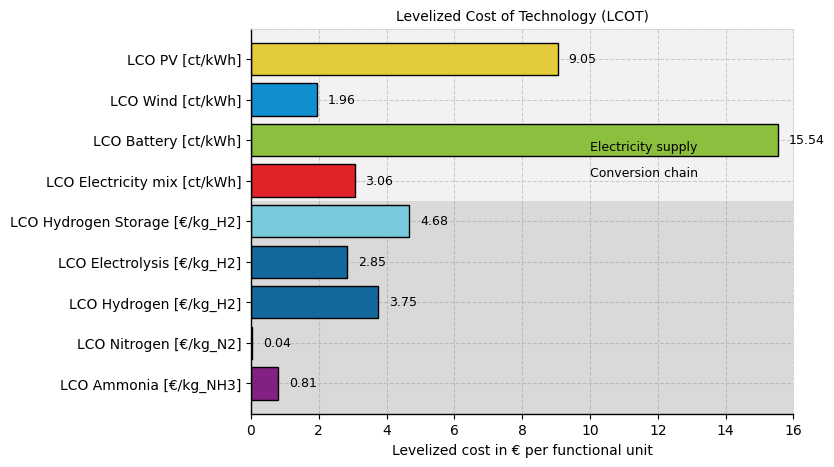

In [61]:
categories = ["LCO Ammonia [€/kg_NH3]", "LCO Nitrogen [€/kg_N2]", "LCO Hydrogen [€/kg_H2]", "LCO Electrolysis [€/kg_H2]", "LCO Hydrogen Storage [€/kg_H2]", "LCO Electricity mix [ct/kWh]", "LCO Battery [ct/kWh]", "LCO Wind [ct/kWh]","LCO PV [ct/kWh]", ]
values = [calc_lcof_hb, calc_lcon_asu, calc_lcoh_h2, calc_lcoh_pem, calc_lcoh_h2s, calc_lcoe_mix*100, calc_lcoe_bat*100, calc_lcoe_wka*100, calc_lcoe_pv*100]
colors = [col_nh3,  col_n2, col_h2, col_pem, col_h2s, col_el, col_bat, col_wka, col_pv]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 4.5
ax.axhspan(cut, 12, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(10, 5.75, "Electricity supply", fontsize=9, color="black")  
ax.text(10, 5.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Levelized cost in € per functional unit", fontsize=10)
plt.title("Levelized Cost of Technology (LCOT)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,16)

plt.savefig("Bilder/calc_lcot_bar.png", dpi=300, bbox_inches='tight')

## 4.5 Gesamtkosten je Energieträger

### 4.5.1 Gesamtkosten je kWh

In [62]:
if (result_pem_flowsum_elin+result_hb_flowsum_elin+result_asu_flowsum_elin) >0:
    calc_cost_el = (calc_cost_pv + calc_cost_wkaon + calc_cost_bat + calc_strombezug_kosten - calc_einnahmen_stromverkauf)/(result_pem_flowsum_elin+result_hb_flowsum_elin+result_asu_flowsum_elin)
else:
    calc_cost_el = 0
print("Gesamtkosten pro kWh Strom: ", f"{calc_cost_el*100:.2f}", "ct/kWh") 
Ergebnisse_df.loc["calc_cost_el", "Wert"] = calc_cost_el*100

Gesamtkosten pro kWh Strom:  3.06 ct/kWh


### 4.5.2 Gesamtkosten je kg H2

In [63]:
if result_hb_flowsum_h2in >0:
    
    calc_cost_h2 = (calc_cost_pem + calc_cost_h2s + calc_cost_el * result_pem_flowsum_elin - calc_einnahmen_h2verkauf)/result_hb_flowsum_h2in
    
else:
    calc_cost_h2 = 0
print("Gesamtkosten pro kg Wasserstoff: ", f"{calc_cost_h2:.2f}", "€/kg") 
Ergebnisse_df.loc["calc_cost_h2", "Wert"] = calc_cost_h2

Gesamtkosten pro kg Wasserstoff:  3.75 €/kg


### 4.5.3 Gesamtkosten je kg N2

In [64]:
if result_hb_flowsum_n2in>0:
    
    calc_cost_n2 = (calc_cost_asu + calc_cost_el * result_asu_flowsum_elin )/result_hb_flowsum_n2in

else:
    calc_cost_n2 = 0
    
print("Gesamtkosten pro kg Stickstoff: ", f"{calc_cost_n2:.2f}", "€/kg") 
Ergebnisse_df.loc["calc_cost_n2", "Wert"] = calc_cost_n2

Gesamtkosten pro kg Stickstoff:  0.04 €/kg


### 4.5.4 Gesamtkosten je Ammoniak

In [65]:
if result_hb_flowsum_nh3out >0:
    
    calc_cost_nh3 = (calc_cost_hb + calc_cost_el * result_hb_flowsum_elin + calc_cost_n2 * result_hb_flowsum_n2in +  calc_cost_h2 * result_hb_flowsum_h2in)/result_hb_flowsum_nh3out

else:
    calc_cost_nh3 =0
    
print("Gesamtkosten pro t Ammonaik: ", f"{calc_cost_nh3*1000:.2f}", "€/t") 
Ergebnisse_df.loc["calc_cost_nh3", "Wert"] = calc_cost_nh3*1000

Gesamtkosten pro t Ammonaik:  807.84 €/t


### 4.5.5 Gesamtkosten je Energieträger Darstellung

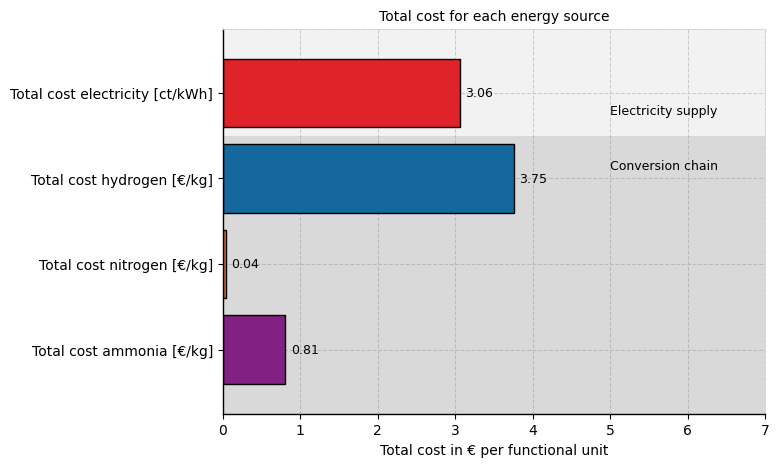

In [66]:
categories = ["Total cost ammonia [€/kg]", "Total cost nitrogen [€/kg]", "Total cost hydrogen [€/kg]", "Total cost electricity [ct/kWh]"]
values = [calc_cost_nh3, calc_cost_n2, calc_cost_h2, calc_cost_el*100]
colors = [col_nh3, col_n2, col_h2, col_el]

fig, ax = plt.subplots(figsize=(7, 5))

cut = 2.5
ax.axhspan(cut, 5, facecolor=col_etc, alpha=0.1)
ax.axhspan(-0.75, cut, facecolor=col_etc, alpha=0.3)
ax.set_ylim([-0.75, len(values)-0.25])
ax.text(5, 2.75, "Electricity supply", fontsize=9, color="black")  
ax.text(5, 2.1, "Conversion chain", fontsize=9, color="black")

bars = ax.barh(categories, values, color=colors, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.2f}",
            va='center', ha='left', fontsize=9, color='black')

# Stil-Einstellungen
ax.spines['top'].set_color('lightgray')
ax.spines['top'].set_linewidth(0.75)
ax.spines['top'].set_linestyle("--")

ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)

ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1)

ax.spines['right'].set_color('lightgray')
ax.spines['right'].set_linewidth(0.75)
ax.spines['right'].set_linestyle("--")

ax.set_axisbelow(True)
ax.grid(which='major', linestyle='--', linewidth=0.75, color='lightgray')
ax.grid(which='minor', linestyle=':', linewidth=0.25, color='lightgray')

plt.xlabel("Total cost in € per functional unit", fontsize=10)
plt.title("Total cost for each energy source", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0,7)

plt.savefig("Bilder/calc_cost_source_bar.png", dpi=300, bbox_inches='tight')

## 4.6 Verkaufspreise

In [67]:
calc_maxprice = calc_ausgaben_gesamt/result_nh3verkauf_flowsum                          # €/a * a/kg_NH3 = €/kg_NH3
print("Maximaler Verkaufspreis zur Bilanznull: ", calc_maxprice.round(2), "€/kg_NH3")
Ergebnisse_df.loc["calc_maxprice", "Wert"] = calc_maxprice

Maximaler Verkaufspreis zur Bilanznull:  0.89 €/kg_NH3


In [68]:
calc_price = (calc_ausgaben_gesamt - calc_einnahmen_stromverkauf - calc_einnahmen_h2verkauf)/result_nh3verkauf_flowsum                          # €/a * a/kg_NH3 = €/kg_NH3
print("Verkaufspreis bei angenommenem Vorverkauf: ", calc_price.round(2), "€/kg_NH3")
Ergebnisse_df.loc["calc_price", "Wert"] = calc_price

Verkaufspreis bei angenommenem Vorverkauf:  0.81 €/kg_NH3


# Export der Ergebnisse

In [69]:
Ergebnisse_df = Ergebnisse_df.reset_index()
Ergebnisse_df = Ergebnisse_df[["Kategorie", "Technologie", "Beschreibung", "Variable", "Wert", "Einheit"]]
Ergebnisse_df["Wert"] = Ergebnisse_df["Wert"].round(6)
Ergebnisse_df.to_csv("Ergebnisse.csv", sep=";", encoding="utf-8-sig", decimal=',', index=False)